# <font color=blue>__Workshop 2: (Bulk) RNA-seq__</font>
###  Machine Learning and Bioinformatics (MLBI) Lab @ DKU, 2025 <br>
### __Practices__
>#### 1. RNA-seq Read alignment (STAR for paired short reads)
>#### 2. Gene expression quantification (Salmon or RSEM)
>#### 3. DEG analysis (DEG and DEIso)
>#### 4. Gene expression quantification through transcriptome assembly (StringTie)
>#### 5. Quantifying alternative splicing using rMATs

<br>

In [ ]:
# Colab 새 런타임에서 mlbi-bitool이 설치되어 있지 않으면 아래 줄의 주석을 풀고 실행하세요.
# !pip install -U mlbi-bitool

In [ ]:
from mlbi_bitool import install_common_bi_tools

install_common_bi_tools("rnaseq")   # short-read RNA-seq 노트북

<!-- MLBI-EDU-NOTE: overview -->
### 실습 목표와 흐름
이 노트북은 short-read bulk RNA-seq 분석의 전형적인 흐름을 교육용 데이터로 압축한 실습입니다. 정렬 기반 분석과 transcriptome 기반 정량을 함께 보면서, 같은 생물학적 질문도 도구 선택에 따라 결과 테이블이 달라질 수 있음을 확인합니다.

- 입력 데이터: CRC cell line paired-end RNA-seq FASTQ, reference genome/annotation
- 주요 도구: STAR, Salmon/RSEM, StringTie, DEG/DEiso, rMATS
- 산출물: BAM, gene/transcript expression matrix, DEG/DEiso 결과, alternative splicing 결과
- 해석 포인트: sample group 이름이 downstream DEG 비교의 기준이 되므로 `vector`, `bcatKO`, `parent` 같은 조건명이 일관되게 유지되는지 확인합니다.


In [1]:
import time, os, copy
import numpy as np
import pandas as pd

## To download datasets for practice
from mlbi_bitool.load_datasets import load_bi_workshop_data, load_workshop_data

import mlbi_bitool.align as aln
import mlbi_bitool.util as utl
from mlbi_bitool import gatk, cnv, geq, deg, deiso, tasm, install_common_bi_tools


https://github.com/combio-dku


### __Download datasets__

<!-- MLBI-EDU-NOTE: data -->
아래 셀은 실습에 필요한 작은 예제 데이터를 내려받습니다. 이미 같은 이름의 폴더가 있으면 다시 받지 않도록 되어 있으므로, 수업 중에는 셀을 여러 번 실행해도 보통 안전합니다.


In [3]:
load_workshop_data()

The item must be one of .. 
   Files_for_GATK
   Files_for_GATK_chr12
   ML_CCLE_CTRPv2
   ML_CancerSEEK
   ML_GDSC
   ML_Genome_to_Fields
   ML_METABRIC
   ML_QM9
   ML_TCGA_BRCA
   RNAseq_CRC_chr17
   RNAseq_CRC_chr17_bam
   RNAseq_CRC_chr17_gexp_results
   RNAseq_NSCLC_chr7
   RNAseq_NSCLC_chr7_bam
   RNAseq_PDAC_chr12
   RNAseq_PDAC_chr12_bam
   RNAseq_pacbio_chr7
   RefGenome_hg38_sel
   WES_NSCLC_chr7
   WES_NSCLC_chr7_bam
   WES_PDAC_chr12
   WES_PDAC_chr12_SNV_CNV_results
   WES_PDAC_chr12_bam
   index_bwa_hg38_sel
   index_rsem_hg38_sel
   index_salmon_hg38_sel
   index_star_hg38_sel 


In [3]:
if not os.path.isdir('RefGenome_hg38_sel'):
    load_bi_workshop_data('BI_RefGenome_hg38_sel')

In [39]:
if not os.path.isdir('RNAseq_CRC_chr17'):
    load_workshop_data('RNAseq_CRC_chr17')

Downloading...
From (original): https://drive.google.com/uc?id=1KbV3o6r4pVPtlQur0xyiniJYS01DsPpM
From (redirected): https://drive.google.com/uc?id=1KbV3o6r4pVPtlQur0xyiniJYS01DsPpM&confirm=t&uuid=a46df786-f9dc-411e-8611-7fabfa98fcf1
To: /mnt/HDD2/Google_drive/BI_training_dev/downloaded
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2.31G/2.31G [02:26<00:00, 15.7MB/s]


Folder extracted to: RNAseq_CRC_chr17


In [2]:
src_dir = 'RefGenome_hg38_sel/'

flst = os.listdir(src_dir)
flst.sort()
flst

['Homo_sapiens_assembly38_chr7_12_17.dict',
 'Homo_sapiens_assembly38_chr7_12_17.fa',
 'Homo_sapiens_assembly38_chr7_12_17.fa.fai',
 'Homo_sapiens_assembly38_chr7_12_17.gene.bed',
 'Homo_sapiens_assembly38_chr7_12_17.gtf',
 'Homo_sapiens_assembly38_chr7_12_17.transcriptome.fa']

In [3]:
src_dir = 'RNAseq_CRC_chr17/'

flst = os.listdir(src_dir)
flst.sort()
flst

['bcatKO-1_chr17_R1.fq.gz',
 'bcatKO-1_chr17_R2.fq.gz',
 'bcatKO-2_chr17_R1.fq.gz',
 'bcatKO-2_chr17_R2.fq.gz',
 'bcatKO-3_chr17_R1.fq.gz',
 'bcatKO-3_chr17_R2.fq.gz',
 'parent-1_chr17_R1.fq.gz',
 'parent-1_chr17_R2.fq.gz',
 'parent-2_chr17_R1.fq.gz',
 'parent-2_chr17_R2.fq.gz',
 'parent-3_chr17_R1.fq.gz',
 'parent-3_chr17_R2.fq.gz',
 'vector-1_chr17_R1.fq.gz',
 'vector-1_chr17_R2.fq.gz',
 'vector-2_chr17_R1.fq.gz',
 'vector-2_chr17_R2.fq.gz',
 'vector-3_chr17_R1.fq.gz',
 'vector-3_chr17_R2.fq.gz']

## __1. Using STAR for RNA-seq__

<!-- MLBI-EDU-NOTE: practice -->
이 단계에서는 splice-aware aligner인 STAR로 RNA-seq read를 genome에 정렬합니다. RNA-seq read는 exon-exon junction에 걸쳐 정렬되는 경우가 많기 때문에 WES/WGS와 달리 splice junction을 고려하는 aligner가 필요합니다.


### Workflow overview
####  
<div>
<img src="attachment:image.png" width="400"/>
</div>

#### Ref. Genome are freely available, e.g., in
1. ENSEMBL: ftp://ftp.ensembl.org/pub/
2. GENCODE: http://www.gencodegenes.org/

#### Download genome and GTF annotation from ENSEMBL
1. Ref genome: ftp://ftp.ensembl.org/pub/release-96/fasta/homo_sapiens/ dna/Homo_sapiens.GRCh38.dna.primary_assembly.fa.gz
2. Annotation: ftp://ftp.ensembl.org/pub/release-96/gtf/homo_sapiens/ Homo_sapiens.GRCh38.96.chr_patch_hapl_scaff.gtf.gz

### __1. Build STAR index of a reference genome__
###  
<div>
<img src="attachment:image.png" width="300"/>
</div>

#### Command: 
STAR --runMode genomeGenerate 
       --genomeFastaFiles PATH_TO_GENOME 
       --sjdbGTFfile PATH_TO_GTF --runThreadN 4
       --sjdbOverhang 100 --genomeDir OUT_DIR
       --outFileNamePrefix OUT_DIR/PREFIX 
- PATH_TO_GENOME: full path to the genome file
- PATH_TO_GTF: full path to the GTF annotation file
- OUT_DIR is the dir. name to save index files
- PREFIX: the prefix to be used for the index files

If successful, you will see the new directory named $OUT_DIR containing some file to be used for read alignment
For detailed options, refer the STAR manual at https://github.com/alexdobin/STAR/blob/master/doc/STARmanual.pdf

In [8]:
!STAR --version

2.7.10a


In [42]:
genome_dir = 'RefGenome_hg38_sel/'
flst = os.listdir(genome_dir)
flst.sort()
flst

['Homo_sapiens_assembly38_chr7_12_17.dict',
 'Homo_sapiens_assembly38_chr7_12_17.fa',
 'Homo_sapiens_assembly38_chr7_12_17.fa.fai',
 'Homo_sapiens_assembly38_chr7_12_17.gtf',
 'Homo_sapiens_assembly38_chr7_12_17.transcriptome.fa']

In [10]:
## Source directory/file description
genome_dir = 'RefGenome_hg38_sel/'
genome_file = genome_dir + 'Homo_sapiens_assembly38_chr7_12_17.fa'
gtf_file = genome_dir + 'Homo_sapiens_assembly38_chr7_12_17.gtf'

## Destination directory/file description
out_dir = "index_star_hg38_sel"

cmd = aln.build_index_star( genome_file, gtf_file, other_opt = None, out_dir = out_dir, verbose = True )
cmd

	/usr/lib/rna-star/bin/STAR-avx2 --runThreadN 8 --runMode genomeGenerate --genomeDir index_star_hg38_sel --genomeFastaFiles RefGenome_hg38_sel/Homo_sapiens_assembly38_chr7_12_17.fa --sjdbGTFfile RefGenome_hg38_sel/Homo_sapiens_assembly38_chr7_12_17.gtf --sjdbOverhang 100
	STAR version: 2.7.10a   compiled: 2022-01-16T16:35:44+00:00 <place not set in Debian package>
Jun 21 00:58:36 ..... started STAR run
Jun 21 00:58:36 ... starting to generate Genome files
Jun 21 00:58:41 ..... processing annotations GTF


!!!!! WARNING: --genomeSAindexNbases 14 is too large for the genome size=375878723, which may cause seg-fault at the mapping step. Re-run genome generation with recommended --genomeSAindexNbases 13


Jun 21 00:58:43 ... starting to sort Suffix Array. This may take a long time...
Jun 21 00:58:44 ... sorting Suffix Array chunks and saving them to disk...
Jun 21 01:07:22 ... loading chunks from disk, packing SA...
Jun 21 01:07:28 ... finished generating suffix array
Jun 21 01:07:28 ... generating Suffix Array index
Jun 21 01:08:49 ... completed Suffix Array index
Jun 21 01:08:49 ..... inserting junctions into the genome indices
Jun 21 01:10:15 ... writing Genome to disk ...
Jun 21 01:10:16 ... writing Suffix Array to disk ...
Jun 21 01:10:17 ... writing SAindex to disk
Jun 21 01:10:18 ..... finished successfully


'STAR --runThreadN 8 --runMode genomeGenerate --genomeDir index_star_hg38_sel --genomeFastaFiles RefGenome_hg38_sel/Homo_sapiens_assembly38_chr7_12_17.fa --sjdbGTFfile RefGenome_hg38_sel/Homo_sapiens_assembly38_chr7_12_17.gtf --sjdbOverhang 100 '

### __2. STAR align (for RNA-seq)__
####  
<div>
<img src="attachment:image.png" width="200"/>
</div>

#### _Command_ : 
**STAR** --runThreadN 4 
       --genomeDir "PATH_TO_INDEX" 
       --readFilesIn "PATH_TO_INPUT1" "PATH_TO_INPUT2"
       --outFileNamePrefix "OUT_DIR" 
       --outSAMattributes XS
       --outSAMstrandField intronMotif 

- The output is a SAM file (Aligned.out.sam stored in OUT_DIR)
- XS field is required for StringTie (a reference based tr assembler)
- XS field contains strand information, i.e., it is either + or -, which is (seems to be) determined by identifying donor (5’ end) and acceptor site (3’ end) of intron.

<div>
<img src="attachment:image.png" width="500"/>
</div>


#### __Example 1: CRC cellline__

In [43]:
src_dir = 'RNAseq_CRC_chr17'
flst = os.listdir(src_dir)
flst.sort()
flst

['bcatKO-1_chr17_R1.fq.gz',
 'bcatKO-1_chr17_R2.fq.gz',
 'bcatKO-2_chr17_R1.fq.gz',
 'bcatKO-2_chr17_R2.fq.gz',
 'bcatKO-3_chr17_R1.fq.gz',
 'bcatKO-3_chr17_R2.fq.gz',
 'parent-1_chr17_R1.fq.gz',
 'parent-1_chr17_R2.fq.gz',
 'parent-2_chr17_R1.fq.gz',
 'parent-2_chr17_R2.fq.gz',
 'parent-3_chr17_R1.fq.gz',
 'parent-3_chr17_R2.fq.gz',
 'vector-1_chr17_R1.fq.gz',
 'vector-1_chr17_R2.fq.gz',
 'vector-2_chr17_R1.fq.gz',
 'vector-2_chr17_R2.fq.gz',
 'vector-3_chr17_R1.fq.gz',
 'vector-3_chr17_R2.fq.gz']

In [44]:
df_fq_pair_list = utl.get_fq_pair_list( src_dir, ext = 'fq.gz', 
                                        r1_key = '_R1', r2_key = '_R2' )
df_fq_pair_list

,fq1,fq2
0,RNAseq_CRC_chr17/bcatKO-1_chr17_R1.fq.gz,RNAseq_CRC_chr17/bcatKO-1_chr17_R2.fq.gz
1,RNAseq_CRC_chr17/bcatKO-2_chr17_R1.fq.gz,RNAseq_CRC_chr17/bcatKO-2_chr17_R2.fq.gz
2,RNAseq_CRC_chr17/bcatKO-3_chr17_R1.fq.gz,RNAseq_CRC_chr17/bcatKO-3_chr17_R2.fq.gz
3,RNAseq_CRC_chr17/parent-1_chr17_R1.fq.gz,RNAseq_CRC_chr17/parent-1_chr17_R2.fq.gz
4,RNAseq_CRC_chr17/parent-2_chr17_R1.fq.gz,RNAseq_CRC_chr17/parent-2_chr17_R2.fq.gz
5,RNAseq_CRC_chr17/parent-3_chr17_R1.fq.gz,RNAseq_CRC_chr17/parent-3_chr17_R2.fq.gz
6,RNAseq_CRC_chr17/vector-1_chr17_R1.fq.gz,RNAseq_CRC_chr17/vector-1_chr17_R2.fq.gz
7,RNAseq_CRC_chr17/vector-2_chr17_R1.fq.gz,RNAseq_CRC_chr17/vector-2_chr17_R2.fq.gz
8,RNAseq_CRC_chr17/vector-3_chr17_R1.fq.gz,RNAseq_CRC_chr17/vector-3_chr17_R2.fq.gz


In [45]:
df_fq_pair_list['RG'] = [f.split('/')[-1].split('-')[0] for f in df_fq_pair_list['fq1']]
df_fq_pair_list['SM'] = [f.split('/')[-1].split('_')[0] for f in df_fq_pair_list['fq1']]
df_fq_pair_list

,fq1,fq2,RG,SM
0,RNAseq_CRC_chr17/bcatKO-1_chr17_R1.fq.gz,RNAseq_CRC_chr17/bcatKO-1_chr17_R2.fq.gz,bcatKO,bcatKO-1
1,RNAseq_CRC_chr17/bcatKO-2_chr17_R1.fq.gz,RNAseq_CRC_chr17/bcatKO-2_chr17_R2.fq.gz,bcatKO,bcatKO-2
2,RNAseq_CRC_chr17/bcatKO-3_chr17_R1.fq.gz,RNAseq_CRC_chr17/bcatKO-3_chr17_R2.fq.gz,bcatKO,bcatKO-3
3,RNAseq_CRC_chr17/parent-1_chr17_R1.fq.gz,RNAseq_CRC_chr17/parent-1_chr17_R2.fq.gz,parent,parent-1
4,RNAseq_CRC_chr17/parent-2_chr17_R1.fq.gz,RNAseq_CRC_chr17/parent-2_chr17_R2.fq.gz,parent,parent-2
5,RNAseq_CRC_chr17/parent-3_chr17_R1.fq.gz,RNAseq_CRC_chr17/parent-3_chr17_R2.fq.gz,parent,parent-3
6,RNAseq_CRC_chr17/vector-1_chr17_R1.fq.gz,RNAseq_CRC_chr17/vector-1_chr17_R2.fq.gz,vector,vector-1
7,RNAseq_CRC_chr17/vector-2_chr17_R1.fq.gz,RNAseq_CRC_chr17/vector-2_chr17_R2.fq.gz,vector,vector-2
8,RNAseq_CRC_chr17/vector-3_chr17_R1.fq.gz,RNAseq_CRC_chr17/vector-3_chr17_R2.fq.gz,vector,vector-3


In [46]:
path_to_idx = 'index_star_hg38_sel'

out_dir = src_dir + '_bam' 
if not os.path.isdir(out_dir):
    os.mkdir(out_dir)
    
df_fq_pair_list['bam'] = None
for j, row in df_fq_pair_list.iterrows():
    
    fq_l = row.fq1
    fq_r = row.fq2
    out_file = '_'.join( fq_l.split('/')[-1].split('_')[:-1] )
    
    print(j, out_file)

    ## STAR option to set Read Group
    opt = '--outSAMattrRGline ID:%s SM:%s LB:U PU:U PL:Illumina ' % (row.RG, row.RG)

    file_out, cmd_lst = aln.align_n_bam_sort_star( fq_l, fq_r, 
                                path_to_idx, out_dir, 
                                out_filename = out_file, 
                                other_opt = opt, verbose = True )

    df_fq_pair_list.loc[j, 'bam'] = file_out
    print('Output file saved to %s' % file_out)


8 vector-3_chr17
	/usr/lib/rna-star/bin/STAR-avx2 --runThreadN 4 --genomeDir index_star_hg38_sel --readFilesIn RNAseq_CRC_chr17/vector-3_chr17_R1.fq.gz RNAseq_CRC_chr17/vector-3_chr17_R2.fq.gz --readFilesCommand zcat --outFileNamePrefix STAR_tmp_vector-3_chr17/ --outSAMattributes XS NH --outSAMstrandField intronMotif --outSAMattrRGline ID:vector SM:vector LB:U PU:U PL:Illumina
	STAR version: 2.7.10a   compiled: 2022-01-16T16:35:44+00:00 <place not set in Debian package>
Jun 21 02:11:20 ..... started STAR run
Jun 21 02:11:20 ..... loading genome
Jun 21 02:11:22 ..... started mapping
Jun 21 02:12:00 ..... finished mapping
Jun 21 02:12:00 ..... finished successfully


[bam_sort_core] merging from 0 files and 4 in-memory blocks...


Output file saved to RNAseq_CRC_chr17_bam/vector-3_chr17.bam


In [47]:
df_fq_pair_list

,fq1,fq2,RG,SM,bam
0,RNAseq_CRC_chr17/bcatKO-1_chr17_R1.fq.gz,RNAseq_CRC_chr17/bcatKO-1_chr17_R2.fq.gz,bcatKO,bcatKO-1,None
1,RNAseq_CRC_chr17/bcatKO-2_chr17_R1.fq.gz,RNAseq_CRC_chr17/bcatKO-2_chr17_R2.fq.gz,bcatKO,bcatKO-2,None
2,RNAseq_CRC_chr17/bcatKO-3_chr17_R1.fq.gz,RNAseq_CRC_chr17/bcatKO-3_chr17_R2.fq.gz,bcatKO,bcatKO-3,None
3,RNAseq_CRC_chr17/parent-1_chr17_R1.fq.gz,RNAseq_CRC_chr17/parent-1_chr17_R2.fq.gz,parent,parent-1,None
4,RNAseq_CRC_chr17/parent-2_chr17_R1.fq.gz,RNAseq_CRC_chr17/parent-2_chr17_R2.fq.gz,parent,parent-2,None
5,RNAseq_CRC_chr17/parent-3_chr17_R1.fq.gz,RNAseq_CRC_chr17/parent-3_chr17_R2.fq.gz,parent,parent-3,None
6,RNAseq_CRC_chr17/vector-1_chr17_R1.fq.gz,RNAseq_CRC_chr17/vector-1_chr17_R2.fq.gz,vector,vector-1,None
7,RNAseq_CRC_chr17/vector-2_chr17_R1.fq.gz,RNAseq_CRC_chr17/vector-2_chr17_R2.fq.gz,vector,vector-2,None
8,RNAseq_CRC_chr17/vector-3_chr17_R1.fq.gz,RNAseq_CRC_chr17/vector-3_chr17_R2.fq.gz,vector,vector-3,RNAseq_CRC_chr17_bam/vector-3_chr17.bam


### __3. Check out aligned BAM__

In [16]:
out_dir 

'RNAseq_CRC_chr17_bam'

In [49]:
np.sort( os.listdir(out_dir) )

array(['bcatKO-1_chr17.bam', 'bcatKO-1_chr17.bam.bai',
       'bcatKO-1_chr17.log', 'bcatKO-2_chr17.bam',
       'bcatKO-2_chr17.bam.bai', 'bcatKO-2_chr17.log',
       'bcatKO-3_chr17.bam', 'bcatKO-3_chr17.bam.bai',
       'bcatKO-3_chr17.log', 'parent-1_chr17.bam',
       'parent-1_chr17.bam.bai', 'parent-1_chr17.log',
       'parent-2_chr17.bam', 'parent-2_chr17.bam.bai',
       'parent-2_chr17.log', 'parent-3_chr17.bam',
       'parent-3_chr17.bam.bai', 'parent-3_chr17.log',
       'vector-1_chr17.bam', 'vector-1_chr17.bam.bai',
       'vector-1_chr17.log', 'vector-2_chr17.bam',
       'vector-2_chr17.bam.bai', 'vector-2_chr17.log',
       'vector-3_chr17.bam', 'vector-3_chr17.bam.bai',
       'vector-3_chr17.log'], dtype='<U22')

In [50]:
### Loading SAM lines
bam_file = out_dir + '/bcatKO-1_chr17.bam'

sam_lines = utl.load_sam_lines( bam_file, n_rd_max = 100000, verbose = True )
df_sam = pd.DataFrame(sam_lines)

Reading  RNAseq_CRC_chr17_bam/bcatKO-1_chr17.bam  . done. read length: 151, 101069


In [52]:
df_sam

,qname,flag,flag_str,rname,pos,mapq,cigar,rnext,pnext,tlen,seq,qual,cN,cD,cI,cS,xs,tags
0,A00479:344:HFW35DSX3:4:1548:29921:36401,99,1100011000001,chr7,12531,3,151M,=,12628,248,CCACTAAAAAAAAGACTCCATTTCAAAAACAAAACTAAAACCAAAA...,":FFFFFFFFFFFFFFFFFFF:,:,FFFFFFFFFF,FFF:F:FFFF:...",0,0,0,0,0,"NH:i:2,RG:Z:bcatK"
1,A00479:344:HFW35DSX3:4:1548:29921:36401,147,1100100100001,chr7,12628,3,151M,=,12531,-248,GTTTCATAGAAAATAAAAGACCAATCAAATACAATAAGCTGCCTTT...,"FF,,FFFF:FFF:FFF,FFFF::FFFF:F::FFFF::FFFFFF:FF...",0,0,0,0,0,"NH:i:2,RG:Z:bcatK"
2,A00479:344:HFW35DSX3:4:1630:26268:15295,99,1100011000001,chr7,14197,3,151M,=,14209,163,GGGTCACAGCTATATTAGAGCTACCTGTGTTCCCCTGTCACTGACA...,FFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFF...,0,0,0,0,0,"NH:i:2,RG:Z:bcatK"
3,A00479:344:HFW35DSX3:4:1630:26268:15295,147,1100100100001,chr7,14209,3,151M,=,14197,-163,TATTAGAGCTACCTGTGTTCCCCTGTCACTGACATTAAAACAAAAA...,"FFFFFFFFFFFFFFFFF,FFFFFFFFFFFFFFFFFFFFFFFFFFFF...",0,0,0,0,0,"NH:i:2,RG:Z:bcatK"
4,A00479:344:HFW35DSX3:4:2369:23240:20760,163,1100010100001,chr7,4768281,255,151M,=,4768333,203,CGCTACCACGCCCGGCTAATTTTTTGTGTTTTTAGTAGAGACGGGG...,FFFFFFFFFFFFFFFFFFFFFFF:FF:FFFFFFFFFFFFFFFFFFF...,0,0,0,0,0,"NH:i:1,RG:Z:bcatK"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44064,A00479:344:HFW35DSX3:4:1601:23954:23375,147,1100100100001,chr17,1345081,255,151M,=,1345072,-160,AGATGCTTGCATCACCTGTAAGTCTAATGGCTTTCAAATGTAATTT...,":F:F,:FFFFFFFF,FFFFFFFFFF,FF:FFFFFFF,FFFFF:,F:...",0,0,0,0,0,"NH:i:1,RG:Z:bcatK"
44065,A00479:344:HFW35DSX3:4:1501:2076:8656,147,1100100100001,chr17,1345081,255,151M,=,1345044,-188,AGATGCTTGCATCACCTGTAAGTATAATGGCTTTCAAATGTAATTT...,"FFFFFFF:F,FF,FFF,,FFF:F,FFFFFF:FFF:F:F,,FFFFFF...",0,0,0,0,0,"NH:i:1,RG:Z:bcatK"
44066,A00479:344:HFW35DSX3:4:1510:9607:20885,147,1100100100001,chr17,1345081,255,151M,=,1345053,-179,AGATGCTTGCATCACCTGTAAGTCTAATGGCTTTCAAATGTAATTT...,"FFFFF,FFFFFFFFFFFFFFFFFFFFF,F:FFFF:FFFFFFFFF:F...",0,0,0,0,0,"NH:i:1,RG:Z:bcatK"
44067,A00479:344:HFW35DSX3:4:1515:5385:16986,147,1100100100001,chr17,1345081,255,151M,=,1345071,-161,AGATGCTTGCATCACCTGTAAGTCTAATGGCTTTCAAATGTAATTT...,FFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFF...,0,0,0,0,0,"NH:i:1,RG:Z:bcatK"


In [53]:
genome_file = 'RefGenome_hg38_sel/Homo_sapiens_assembly38_chr7_12_17.fa'
genome = utl.load_genome(genome_file, verbose =True)

Num.Chr =  3  loaded                             


In [54]:
b = df_sam['cD'] > 0
df_sam_sel = df_sam.loc[b]

In [55]:
df_sam_sel.iloc[:5]

,qname,flag,flag_str,rname,pos,mapq,cigar,rnext,pnext,tlen,seq,qual,cN,cD,cI,cS,xs,tags
21,A00930:299:HFWTGDSX3:4:1409:28167:23813,83,1100101000001,chr7,20003162,255,27S94M1D30M,=,20003162,-125,ATTTCAGACGTGTGCTCTTCCGATCTGCTCCACCCATAGAAGCACA...,":,FF,FF:,:::F,:F,FF,:F,F,F,FF::F:,,:,F,FF,:F,F...",0,1,0,1,0,"NH:i:1,RG:Z:bcatK"
38,A00479:344:HFW35DSX3:4:2172:3522:27790,99,1100011000001,chr7,55221033,255,136M4D15M,=,55221063,183,GTCAGGCGTGGCGGCGCGCGCCTGCAATCGCAGGCACTCGGCAGGC...,FFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFF...,0,1,0,0,0,"NH:i:1,RG:Z:bcatK"
39,A00479:344:HFW35DSX3:4:2172:3522:27790,147,1100100100001,chr7,55221063,255,106M4D43M2S,=,55221033,-183,CAGGCACTCGGCAGGCTGAGGCAGGAGAATCAGGCAGGGAGGTTGC...,"FFFFF:FFFFFFF:FFFFFFFFFFFFFFFFFFFFFFFFFFFF,FFF...",0,1,0,1,0,"NH:i:1,RG:Z:bcatK"
325,A00930:299:HFWTGDSX3:4:2211:10619:25676,83,1100101000001,chr7,128502438,255,18S96M1D35M2S,=,128502302,-268,GTGTAAATGCCGGTGTTTGCATTTTCATTTAATACTTACAGGGGTT...,":F:F,:FFF,,FF,,F,,,,:,FF,:,,F,,FFF,,FFFFFF,,FF...",0,1,0,2,0,"NH:i:1,RG:Z:bcatK"
326,A00479:344:HFW35DSX3:4:1134:8621:24909,163,1100010100001,chr7,128502518,255,16M1D115M20S,=,128502518,132,GATATTTTCCTGACAAAAAAAAATGACCCTGTAGACAGCATCAAAA...,"FFFFFFFFFFFF,FFF,FFFFFFFFFFFFFFF:FFF:FFFFFFFF:...",0,1,0,1,0,"NH:i:1,RG:Z:bcatK"


In [23]:
for k in range(5): 
    line =  df_sam_sel.iloc[k]
    cigar = line.cigar
    res, rs, qs, type_cnt = utl.get_seq_from_genome(genome, line)
    es = utl.get_error_seq( rs, qs )
    
    print(cigar)
    print('RSEQ: ', rs, ' Len: ', len(rs))
    print('QSEQ: ', qs, ' Len: ', len(qs))
    print('ESEQ: ', es, ' Len: ', len(es))
    print(' ')
    

27S94M1D30M
RSEQ:  ATTTCAGACGTGTGCTCTTCCGATCTGCTCCACCCATAGAAGCACACTTTGTGAGAACCAATGGGAAGGAGCCTGAGCTGCTGGAACCTATTCCGTATGAATTCATGGCATAATAGGTGTT AAAAAAAAAAATAAAGGACCTCTGGGCTAC  Len:  152
QSEQ:                             CTCCACCCAGAGAAGCACACTTTGTGAGAACCAATGGGAAGGAGCCTGAGCTGCTGGAACCTATTCCCTATGAATTCATGGCATAATAGGTGTTAAAAAAAAAAAATAAAGGACCTCTGGGCTAC  Len:  152
ESEQ:  xxxxxxxxxxxxxxxxxxxxxxxxxxx_________e_________________________________________________________e__________________________d______________________________  Len:  152
 
136M4D15M
RSEQ:  GTCAGGCGTGGCGGCGCGCGCCTGCAATCGCAGGCACTCGGCAGGCTGAGGCAGGAGAATCAGGCAGGGAGGTTGCAGTGAGCCGAGATGGCAGCAGTACAGTCCAGCTTCGGCTCGGCTTGAGAGGGAGACCGTG    GAGGGAGACGGAGAC  Len:  155
QSEQ:  GTCAGGCGTGGCGGCGCGTGCCTGCAATCGCAGGCACTCGGCAGGCTGAGGCAGGAGAATCAGGCAGGGAGGTTGCAGTGAGCCGAGATGGCAGCAGTACAGTCCAGCTTCGGCTCCGCATGAGAGGGAGACCGTGGGGAGAGGGAGACGGAGAC  Len:  155
ESEQ:  __________________e_________________________________________________________________________________________

### __4. Use IGV to check alignment__

1. (A) __If you're using Colab__, store BAM files to your Google drive 

In [26]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    os.listdir('/content/drive/Mydrive')
except:
    pass

1. (B) Or, download BAM files and their bam index to your local PC
2. Ctrl + click: https://igv.org/
3. Upload BAM and its index to Web IGV (Tracks)
4. Navigate to check read alignment 

### Homework
1. 위의 SAM line을 parsing하여 I 또는 D가 포함된 read를 골라 Data Frame으로 요약하라. <br>
   Data Frame의 각 열은 chr, 시작 position, length를 포함하도록 하라
2. 위의 SAM line을 parsing하여 chimeric read를 골라 이에 포함된 M의 길이에 대한 histogram을 그려보아라.<br> 
   (참고 N이 포함된 경우 M은 두개 이상이 있음)
   
#### 과제 제출: 
실행 결과를 확인할 수 있는 jupyer notebook 파일을 Lab_share 폴더의 Homework 폴더 안에 'yyyymmdd-BI-Homework-practice번호-본인이름.ipynb' 파일명으로 저장하라. 

### Homework
Practice 1의 Genome과 위의 SAM line을 이용하여 다음의 과제를 수행하라. <br>
1. N이 포함된 read에 대해 Intron의 Donor site (5' end of intron)와 acceptor site (3' end of intron)의 두 nucleotide를 확인하여 이를 Data Frame으로 요약하라. Data Frame의 각 열은 chr, intron의 start position, intron의 end position, donor site 2nt(string), acceptor site 2nt(string), XS 값을 포함해야 한다.
2. 1의 결과로부터 donor site 2nt(string)와 acceptor site 2nt(string) 쌍의 종류를 모두 확인하고 각 경우의 frequency가 어떻게 되는지 Data Frame으로 요약하라. 힌트: donor site 2nt(string)와 acceptor site 2nt(string) 쌍은 두개 string을 하나의 string(4nt)로 합쳐서 카운트하면 될듯. 주의: XS field의 값에 따라 donor site와 acceptor site nt의 위치를 바꾸고 reverse complement를 취해야 하며 이를 위해 다음의 코드를 활용할 수 있다.
3. 위의 함수 get_seq_from_genome_o2를 약간 수정하여 SAM line의 cigar string이 N을 포함할 경우 QSEQ의 ~~ 양쪽에 donor site 2nt(string)와 acceptor site 2nt(string)가 보이도록 하고 이에 상응한 RSEQ의 위치에는 XS field의 값(+ 또는 -)가 적히도록 하라.

#### 과제 제출: 
실행 결과를 확인할 수 있는 jupyer notebook 파일을 Lab_share 폴더의 Homework 폴더 안에 'yyyymmdd-BI-Homework-practice번호-본인이름.ipynb' 파일명으로 저장하라. 

In [27]:
NT_lst = 'ACGTN'
NT_dict = { 'A':'T', 'C':'G', 'G':'C', 'T':'A', 'N':'N' }

def Reverse_Complement( nt_str ):
    return ''.join( [NT_dict[nt] for nt in nt_str] )[::-1]

In [28]:
Reverse_Complement('ACCTGN')

'NCAGGT'

## __2. Gene/Transcript expression quantification__
####  
<div>
<img src="attachment:exp_quantification2.png" width="500"/>
</div>

1. First need to prepare reference transcriptome using genome and GTF annotation and build its index file
2. Then, align reads to the ref. transcriptome  using STAR or bowtie to count reads aligned/alignable to each transcript

<!-- MLBI-EDU-NOTE: practice -->
이 단계에서는 transcriptome reference를 만들고 sample별 expression matrix를 생성합니다. Gene-level matrix는 DEG 분석에 직관적이고, transcript-level matrix는 isoform 변화와 DEiso 분석에 사용됩니다.


### __1.A Generate index files to reference "transcriptome"__
###   
<div>
<img src="attachment:image.png" width="220"/>
</div>

#### _Command_
__rsem-prepare-reference__ -p 4 --star --polyA --star-gzipped-read-file --gtf "GTF" "REF_GENOME" "IDX_PREFIX"

- GTF: GTF file
- REF_GENOME: Genome fasta file
- IDX_PREFIX: prefix used for output index files

In [5]:
method_selection = 'salmon' ## 'salmon' or 'rsem'

tr_index_dir = f'index_{method_selection}_hg38_sel'
tr_index_dir

'index_salmon_hg38_sel'

In [13]:
## Source directory/file description
genome_dir = 'RefGenome_hg38_sel'
genome_file = genome_dir + '/Homo_sapiens_assembly38_chr7_12_17.fa'
gtf_file = genome_dir + '/Homo_sapiens_assembly38_chr7_12_17.gtf'

if method_selection == 'salmon':
    path_to_idx, cmds = geq.salmon_PrepRef( genome_file, gtf_file,
                                            index_dir = tr_index_dir,
                                            verbose = True )
else:
    path_to_idx, cmds  =  geq.RSEM_PrepRef( genome_file, gtf_file,
                                            index_dir = tr_index_dir,
                                            verbose = True )    

[2026-06-21 01:56:29.509] [jLog] [warning] The salmon index is being built without any decoy sequences.  It is recommended that decoy sequence (either computed auxiliary decoy sequence or the genome of the organism) be provided during indexing. Further details can be found at https://salmon.readthedocs.io/en/latest/salmon.html#preparing-transcriptome-indices-mapping-based-mode.
[2026-06-21 01:56:29.509] [jLog] [info] building index
out : index_salmon_hg38_sel
[2026-06-21 01:56:29.509] [puff::index::jointLog] [info] Running fixFasta

[Step 1 of 4] : counting k-mers
[2026-06-21 01:56:29.785] [puff::index::jointLog] [warning] Entry with header [ENST00000632684], had length less than equal to the k-mer length of 31 (perhaps after poly-A clipping)
[2026-06-21 01:56:30.139] [puff::index::jointLog] [warning] Entry with header [ENST00000543745], had length less than equal to the k-mer length of 31 (perhaps after poly-A clipping)
[2026-06-21 01:56:30.286] [puff::index::jointLog] [warning] Entry

Threads = 2
Vertex length = 31
Hash functions = 5
Filter size = 536870912
Capacity = 2
Files: 
index_salmon_hg38_sel/ref_k31_fixed.fa
--------------------------------------------------------------------------------
Round 0, 0:536870912
Pass	Filling	Filtering
1	6	13	
2	1	0
True junctions count = 128657
False junctions count = 111643
Hash table size = 240300
Candidate marks count = 1093384
--------------------------------------------------------------------------------
Reallocating bifurcations time: 0
True marks count: 884182
Edges construction time: 0
--------------------------------------------------------------------------------
Distinct junctions = 128657



allowedIn: 15
Max Junction ID: 152842
seen.size():1222745 kmerInfo.size():152843
approximateContigTotalLength: 14638993
counters for complex kmers:
(prec>1 & succ>1)=7483 | (succ>1 & isStart)=136 | (prec>1 & isEnd)=137 | (isStart & isEnd)=24
contig count: 193639 element count: 26704416 complex nodes: 7780
# of ones in rank vector: 193638
[2026-06-21 01:56:53.331] [puff::index::jointLog] [info] Starting the Pufferfish indexing by reading the GFA binary file.
[2026-06-21 01:56:53.331] [puff::index::jointLog] [info] Setting the index/BinaryGfa directory index_salmon_hg38_sel
size = 26704416
-----------------------------------------
| Loading contigs | Time = 1.3034 ms
-----------------------------------------
size = 26704416
-----------------------------------------
| Loading contig boundaries | Time = 630.33 us
-----------------------------------------
Number of ones: 193638
Number of ones per inventory item: 512
Inventory entries filled: 379
193638
[2026-06-21 01:56:53.367] [puff::index

for info, total work write each  : 2.331    total work inram from level 3 : 4.322  total work raw : 25.000 
Bitarray       109490368  bits (100.00 %)   (array + ranks )
final hash             0  bits (0.00 %) (nb in final hash 0)


[2026-06-21 01:56:57.851] [puff::index::jointLog] [info] finished populating pos vector
[2026-06-21 01:56:57.851] [puff::index::jointLog] [info] writing index components
[2026-06-21 01:56:57.900] [puff::index::jointLog] [info] finished writing dense pufferfish index
[2026-06-21 01:56:57.911] [jLog] [info] done building index


### __1.B Quantifying gene/transcript expression__ 
###  
<div>
<img src="attachment:image.png" width="250"/>
</div>

#### Use index files to ref. transcriptome generated by rsem-prepare-ref.

#### _Command_
**rsem-calculate-expression** -p 4 --paired-end –-star "INPUT_FQ1" "INPUT_FQ2" "IDX_PREFIX" "RES_PREFIX"

**or**

**rsem-calculate-expression** -p 4 --paired-end –-star --alignments "INPUT_BAM" "IDX_PREFIX" "RES_PREFIX"

- INPUT_FQ1: Fastq file 1 
- INPUT_FQ2: Fastq file 2
- INPUT_BAM: BAM file
- IDX_PREFIX: prefix used for index files
- RES_PREFIX: prefix used for output files


#### _Outputs_
- RES_ PREFIX.genes.results
- RES_ PREFIX.isoforms.results
- RES_ PREFIX.transcript.sorted. (bam, bam.bai)

#### __A. Prepare data__

In [56]:
## Check data folder
src_dir = 'RNAseq_CRC_chr17'
dlst = os.listdir(src_dir)
dlst.sort()
dlst

['bcatKO-1_chr17_R1.fq.gz',
 'bcatKO-1_chr17_R2.fq.gz',
 'bcatKO-2_chr17_R1.fq.gz',
 'bcatKO-2_chr17_R2.fq.gz',
 'bcatKO-3_chr17_R1.fq.gz',
 'bcatKO-3_chr17_R2.fq.gz',
 'parent-1_chr17_R1.fq.gz',
 'parent-1_chr17_R2.fq.gz',
 'parent-2_chr17_R1.fq.gz',
 'parent-2_chr17_R2.fq.gz',
 'parent-3_chr17_R1.fq.gz',
 'parent-3_chr17_R2.fq.gz',
 'vector-1_chr17_R1.fq.gz',
 'vector-1_chr17_R2.fq.gz',
 'vector-2_chr17_R1.fq.gz',
 'vector-2_chr17_R2.fq.gz',
 'vector-3_chr17_R1.fq.gz',
 'vector-3_chr17_R2.fq.gz']

In [57]:
df_fq_pair_list = utl.get_fq_pair_list( src_dir, ext = 'fq.gz', 
                                    r1_key = '_R1', r2_key = '_R2' )

df_fq_pair_list['RG'] = [f.split('/')[-1].split('-')[0] for f in df_fq_pair_list['fq1']]
df_fq_pair_list['SM'] = [f.split('/')[-1].split('_')[0] for f in df_fq_pair_list['fq1']]

df_fq_pair_list

,fq1,fq2,RG,SM
0,RNAseq_CRC_chr17/bcatKO-1_chr17_R1.fq.gz,RNAseq_CRC_chr17/bcatKO-1_chr17_R2.fq.gz,bcatKO,bcatKO-1
1,RNAseq_CRC_chr17/bcatKO-2_chr17_R1.fq.gz,RNAseq_CRC_chr17/bcatKO-2_chr17_R2.fq.gz,bcatKO,bcatKO-2
2,RNAseq_CRC_chr17/bcatKO-3_chr17_R1.fq.gz,RNAseq_CRC_chr17/bcatKO-3_chr17_R2.fq.gz,bcatKO,bcatKO-3
3,RNAseq_CRC_chr17/parent-1_chr17_R1.fq.gz,RNAseq_CRC_chr17/parent-1_chr17_R2.fq.gz,parent,parent-1
4,RNAseq_CRC_chr17/parent-2_chr17_R1.fq.gz,RNAseq_CRC_chr17/parent-2_chr17_R2.fq.gz,parent,parent-2
5,RNAseq_CRC_chr17/parent-3_chr17_R1.fq.gz,RNAseq_CRC_chr17/parent-3_chr17_R2.fq.gz,parent,parent-3
6,RNAseq_CRC_chr17/vector-1_chr17_R1.fq.gz,RNAseq_CRC_chr17/vector-1_chr17_R2.fq.gz,vector,vector-1
7,RNAseq_CRC_chr17/vector-2_chr17_R1.fq.gz,RNAseq_CRC_chr17/vector-2_chr17_R2.fq.gz,vector,vector-2
8,RNAseq_CRC_chr17/vector-3_chr17_R1.fq.gz,RNAseq_CRC_chr17/vector-3_chr17_R2.fq.gz,vector,vector-3


#### __B1. Run salmon or RSEM__

In [58]:
method_selection = 'salmon' ## 'salmon' or 'rsem'

tr_index_dir = f'index_{method_selection}_hg38_sel'
display( tr_index_dir )

## Destination directory/file description
src_dir = 'RNAseq_CRC_chr17'
out_dir = src_dir + f'_{method_selection}'
display( out_dir )

'index_salmon_hg38_sel'

'RNAseq_CRC_chr17_salmon'

In [59]:
col = f'{method_selection}_res'
df_fq_pair_list[col] = ''

for j, row in df_fq_pair_list.iterrows():
    
    fq_l = row.fq1
    fq_r = row.fq2
    out_file_prefix = f'{out_dir}/' + '_'.join( fq_l.split('/')[-1].split('_')[:-1] )
    
    print(j, out_file_prefix)

    if method_selection == 'salmon':
        file_out, cmds = geq.salmon_CalcExp( fq_l, fq_r, tr_index_dir, 
                                             out_file_prefix, \
                                             p = 6, verbose = False)
    else:
        file_out, cmds = geq.RSEM_CalcExp( fq_l, fq_r, tr_index_dir, 
                                           out_file_prefix, 
                                           p = 6, verbose = False)
        
    df_fq_pair_list.loc[j, col] = file_out
    

8 RNAseq_CRC_chr17_salmon/vector-3_chr17
running salmon quant .. 
Expression info. saved to .. 
   RNAseq_CRC_chr17_salmon/vector-3_chr17.tr_exp.tsv 


In [60]:
df_fq_pair_list

,fq1,fq2,RG,SM,salmon_res
0,RNAseq_CRC_chr17/bcatKO-1_chr17_R1.fq.gz,RNAseq_CRC_chr17/bcatKO-1_chr17_R2.fq.gz,bcatKO,bcatKO-1,
1,RNAseq_CRC_chr17/bcatKO-2_chr17_R1.fq.gz,RNAseq_CRC_chr17/bcatKO-2_chr17_R2.fq.gz,bcatKO,bcatKO-2,
2,RNAseq_CRC_chr17/bcatKO-3_chr17_R1.fq.gz,RNAseq_CRC_chr17/bcatKO-3_chr17_R2.fq.gz,bcatKO,bcatKO-3,
3,RNAseq_CRC_chr17/parent-1_chr17_R1.fq.gz,RNAseq_CRC_chr17/parent-1_chr17_R2.fq.gz,parent,parent-1,
4,RNAseq_CRC_chr17/parent-2_chr17_R1.fq.gz,RNAseq_CRC_chr17/parent-2_chr17_R2.fq.gz,parent,parent-2,
5,RNAseq_CRC_chr17/parent-3_chr17_R1.fq.gz,RNAseq_CRC_chr17/parent-3_chr17_R2.fq.gz,parent,parent-3,
6,RNAseq_CRC_chr17/vector-1_chr17_R1.fq.gz,RNAseq_CRC_chr17/vector-1_chr17_R2.fq.gz,vector,vector-1,
7,RNAseq_CRC_chr17/vector-2_chr17_R1.fq.gz,RNAseq_CRC_chr17/vector-2_chr17_R2.fq.gz,vector,vector-2,
8,RNAseq_CRC_chr17/vector-3_chr17_R1.fq.gz,RNAseq_CRC_chr17/vector-3_chr17_R2.fq.gz,vector,vector-3,RNAseq_CRC_chr17_salmon/vector-3_chr17.tr_exp.tsv


#### __C. Aggregate Salmon/RSEM results__

In [61]:
out_dir = src_dir + f'_{method_selection}'

In [62]:
genome_dir = 'RefGenome_hg38_sel'
gtf_file = genome_dir + '/Homo_sapiens_assembly38_chr7_12_17.gtf'

if method_selection == 'salmon':
    df_tr_exp, df_g_exp = geq.aggregate_salmon_results(out_dir, gtf_file, col = 'TPM')
else:
    df_tr_exp, df_g_exp = geq.aggregate_rsem_results(out_dir, gtf_file, col = 'TPM')

Loading GTF ... done 465202 lines. 
34718 transcripts found


In [63]:
df_tr_exp.head()

,bcatKO-1_chr17,bcatKO-2_chr17,bcatKO-3_chr17,parent-1_chr17,parent-2_chr17,parent-3_chr17,vector-1_chr17,vector-2_chr17,vector-3_chr17
TranscriptName,,,,,,,,,
NTS-201,0.0,0.0,0.0,0.0,0.000000,0.00000,0.000000,0.000000,0.000000
RNF10-214,0.0,0.0,0.0,0.0,0.000000,0.00000,0.000000,0.000000,0.000000
KANSL2-213,0.0,0.0,0.0,0.0,0.000000,0.00000,0.000000,0.000000,0.000000
AC004797.1-201,0.0,0.0,0.0,0.0,0.275334,0.29964,0.241893,0.196213,0.492888
GFAP-201,0.0,0.0,0.0,0.0,0.000000,0.00000,0.000000,0.000000,0.000000


In [64]:
df_g_exp.head()

,bcatKO-1_chr17,bcatKO-2_chr17,bcatKO-3_chr17,parent-1_chr17,parent-2_chr17,parent-3_chr17,vector-1_chr17,vector-2_chr17,vector-3_chr17
MTCO1P39,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
AC005189.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
AC007114.2,0.000000,0.000000,0.000000,0.148163,0.000000,0.000000,0.00000,0.000000,0.000000
BRAF,0.266533,0.153792,0.741286,0.487968,0.093505,0.409806,0.27422,0.275658,0.264593
SAMD11P1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000


In [65]:
df_g_exp.to_csv(f'exp_g_{method_selection}.csv')
df_tr_exp.to_csv(f'exp_t_{method_selection}.csv')

#### __Compare salmon with rsem results__

In [66]:
import matplotlib.pyplot as plt

In [67]:
if os.path.isfile('exp_t_rsem.csv'):
    df_t_rsem = pd.read_csv( 'exp_t_rsem.csv', index_col = 0 )
    tns_rsem = df_t_rsem.index.values.tolist()
    
if os.path.isfile('exp_t_salmon.csv'):
    df_t_salmon = pd.read_csv( 'exp_t_salmon.csv', index_col = 0 )
    tns_salmon = df_t_salmon.index.values.tolist()

if os.path.isfile('exp_t_rsem.csv') and os.path.isfile('exp_t_salmon.csv'):
    tns_cmn = list(set(tns_rsem).intersection(tns_salmon))
    display( len(tns_cmn), len(tns_rsem), len(tns_salmon) )

    c = df_t_salmon.columns.values.tolist()[0]

    ro = 0.001
    plt.figure( figsize = (5,5) )
    plt.scatter( np.log2( ro + df_t_rsem.loc[tns_cmn, c] ), np.log2( ro + df_t_salmon.loc[tns_cmn, c]) )
    plt.grid()

## __3. Differentially expressed genes analysis__

<!-- MLBI-EDU-NOTE: practice -->
이 단계에서는 조건 간 발현 차이를 통계적으로 요약합니다. `ref_condition`은 기준 조건을 의미하며, logFC의 부호와 volcano plot 해석이 이 기준에 따라 달라집니다.


#### __A. DEG__

In [68]:
t_or_g = 't'
method_selection = 'salmon' ## 'salmon' or 'rsem'

df_g_exp = pd.read_csv( f'exp_{t_or_g}_{method_selection}.csv', index_col = 0 )
df_tr_exp = pd.read_csv( f'exp_{t_or_g}_{method_selection}.csv', index_col = 0 )

In [78]:
df_expr = np.log2( 1 + df_g_exp )
group = [c.split('-')[0] for c in df_expr.columns]
np.array(group)

array(['bcatKO', 'bcatKO', 'bcatKO', 'parent', 'parent', 'parent',
       'vector', 'vector', 'vector'], dtype='<U6')

In [79]:
dft = df_expr.transpose().copy(deep = True)
dft.insert(0, 'Group', group )
# df_expr = dft.transpose()

In [80]:
df_expr.transpose()

TranscriptName,NTS-201,RNF10-214,KANSL2-213,AC004797.1-201,GFAP-201,STAG3L4-201,METRNL-204,FMC1-205,TARBP2-220,AC079035.1-201,...,MAP3K14-AS1-207,IFT22-205,METTL27-203,IMPDH1-208,EP400P1-209,AC004160.1-207,SUN1-218,ST8SIA1-201,TMC8-202,GNPTAB-209
bcatKO-1_chr17,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.419650,0.0
bcatKO-2_chr17,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.102736,0.0
bcatKO-3_chr17,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.166850,0.0
parent-1_chr17,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.190437,0.0
parent-2_chr17,0.0,0.0,0.0,0.350875,0.0,0.0,0.0,0.0,0.0,0.0,...,4.613466,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.475622,0.0
parent-3_chr17,0.0,0.0,0.0,0.378112,0.0,0.0,0.0,0.0,0.0,0.0,...,4.265003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.620623,0.0
vector-1_chr17,0.0,0.0,0.0,0.312541,0.0,0.0,0.0,0.0,0.0,0.0,...,3.881504,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.883637,0.0
vector-2_chr17,0.0,0.0,0.0,0.258474,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.283686,0.0
vector-3_chr17,0.0,0.0,0.0,0.578106,0.0,0.0,0.0,0.0,0.0,0.0,...,4.157910,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.728367,0.0


In [82]:
dct_deg, dct_deg_all = deg.simple_DEG( df_expr, group, 
                                       ref_condition = 'vector', ## None for One-vs-the-Rest 
                                       pval_cutoff = 0.05,
                                       logFC_cutoff = 0.5,
                                       test_method = "ttest",
                                       corr_method = "fdr_bh")

## dct_deg contains only significant DEGs only
## dct_deg_all contains in-significant genes as well

dct_deg.keys()

### MODE: one-vs-reference (vector) ###
Significant DEGs (bcatKO vs vector) = 115 (up 32, down 83) genes.
Significant DEGs (parent vs vector) = 203 (up 129, down 74) genes.


dict_keys(['bcatKO_vs_vector', 'parent_vs_vector'])

In [83]:
dct_deg.keys()

dict_keys(['bcatKO_vs_vector', 'parent_vs_vector'])

In [84]:
def get_deg_summary( dct_deg, col = "pval_adj" ):
    
    ilst = []
    for k in dct_deg.keys():
        display(dct_deg[k].shape)
        ilst = ilst + dct_deg[k].index.values.tolist()
        cols = dct_deg[k].columns.values.tolist()
    
    ilst = list(set(ilst))
    
    df_res = pd.DataFrame( 1., index = ilst, columns = list(dct_deg.keys()))
    for k in dct_deg.keys():
        ilst = dct_deg[k].index.values.tolist()
        df_res.loc[ilst, k] = dct_deg[k][col]
    
    return df_res


In [85]:
get_deg_summary( dct_deg, col = "pval_adj" )

(115, 5)

(203, 5)

,bcatKO_vs_vector,parent_vs_vector
SARM1-208,1.000000,0.026265
ITGA3-205,1.000000,0.000993
LUC7L3-211,0.008773,0.009002
SERPINF1-201,1.000000,0.042828
BAIAP2-228,0.032855,0.048082
...,...,...
EFNB3-201,1.000000,0.020136
THRA-201,1.000000,0.044330
ARRB2-214,1.000000,0.023257
TOM1L1-216,0.003931,0.024315


In [86]:
item = 'bcatKO_vs_vector'
dct_deg[item].to_csv(f'deg_{t_or_g}_{method_selection}.csv')

In [87]:
dct_deg[item].head()

,logFC,mean_ref,mean_test,pval,pval_adj
gene,,,,,
ZNF18-204,-4.924568,4.924568,0.000000,1.486277e-09,0.000014
PNPO-201,-6.827153,6.827153,0.000000,8.231934e-09,0.000026
CCDC40-212,1.701957,0.000000,1.701957,2.101073e-07,0.000396
TUBD1-206,-2.195211,2.195211,0.000000,1.771897e-07,0.000396
RFNG-202,-4.908290,4.908290,0.000000,1.004465e-06,0.001184


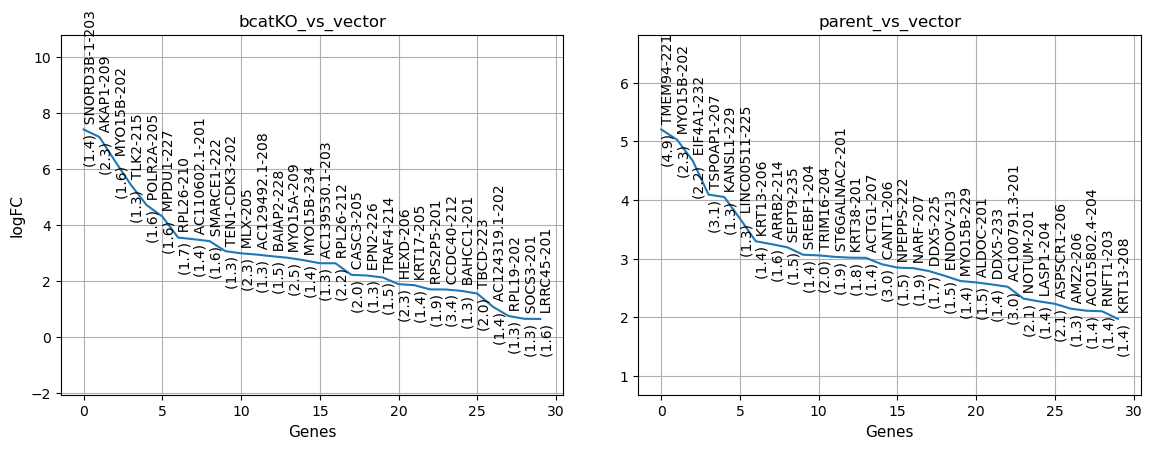

In [88]:
score_ref = 'logFC' # 'pval_adj' or 'logFC'
deg.plot_deg( dct_deg, reference = score_ref, n_genes_to_show = 30, pval_cutoff = 0.05, 
              figsize = (6,4), dpi = 100, text_fs = 10, title_fs = 12, label_fs = 11, 
              tick_fs = 10, ncols = 2, wspace = 0.15, hspace = 0.2, 
              deg_stat_dct = None, show_log_pv = True )

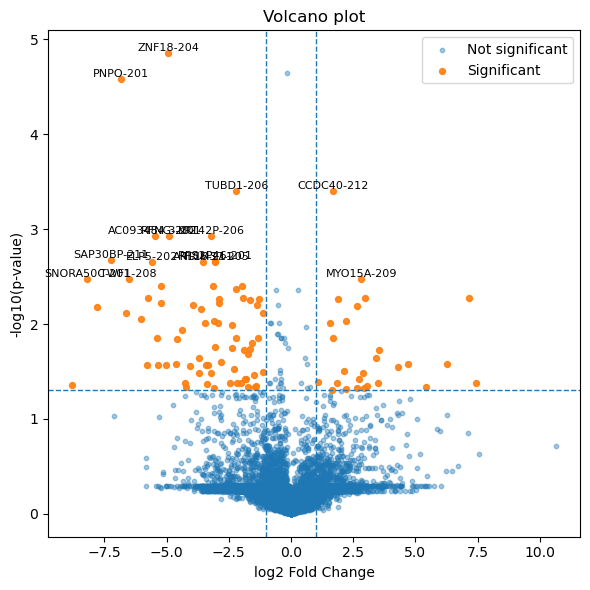

In [89]:
deg.plot_volcano(
    dct_deg_all[item],
    logFC_col = "logFC",
    pval_col = "pval_adj",    
    gene_col = None,          
    pval_cutoff = 0.05,
    logFC_cutoff = 1.0,
    top_n_labels = 15,
    figsize=(6, 6),
    # xlim = [-5, 5],
    # ylim = [0, 3],
    title = "Volcano plot",
)

#### __B. DEiso__

In [90]:
df = df_tr_exp
df.head()

,bcatKO-1_chr17,bcatKO-2_chr17,bcatKO-3_chr17,parent-1_chr17,parent-2_chr17,parent-3_chr17,vector-1_chr17,vector-2_chr17,vector-3_chr17
TranscriptName,,,,,,,,,
NTS-201,0.0,0.0,0.0,0.0,0.000000,0.00000,0.000000,0.000000,0.000000
RNF10-214,0.0,0.0,0.0,0.0,0.000000,0.00000,0.000000,0.000000,0.000000
KANSL2-213,0.0,0.0,0.0,0.0,0.000000,0.00000,0.000000,0.000000,0.000000
AC004797.1-201,0.0,0.0,0.0,0.0,0.275334,0.29964,0.241893,0.196213,0.492888
GFAP-201,0.0,0.0,0.0,0.0,0.000000,0.00000,0.000000,0.000000,0.000000


In [91]:
groups = [c.split('-')[0] for c in df.columns]
np.array( groups )

array(['bcatKO', 'bcatKO', 'bcatKO', 'parent', 'parent', 'parent',
       'vector', 'vector', 'vector'], dtype='<U6')

In [92]:
ref_group = 'vector'
df_res_dct = deiso.DEiso_anal( df, groups, ref_group = ref_group,
                         norm = False, log = True, n_pca_comp = 2, 
                         verbose = True )

DEiso done (4) .. 367                      


In [93]:
df_res_dct.keys()

dict_keys(['bcatKO_vs_vector', 'parent_vs_vector'])

In [94]:
item = 'bcatKO_vs_vector'
df_res = df_res_dct[item].sort_values('pval')
b = df_res['pval'] <= 0.05
df_res = df_res.loc[b, :]
df_res

,stat,pval,Niso,DoF,F-stat,pval_adj
ADORA2B,166.095309,0.000847,2,3,166.095309,0.080439
LINC00674,106.592286,0.001635,2,3,106.592286,0.153664
RPL27,88.820347,0.00214,8,3,88.820347,0.199040
NUFIP2,76.003646,0.002692,2,3,76.003646,0.247709
KPNB1,74.629042,0.002766,14,3,74.629042,0.251682
H3F3B,61.672224,0.003659,13,3,61.672224,0.329299
ITGB4,38.00626,0.007398,13,3,38.00626,0.658458
AC008105.1,33.497927,0.008873,2,3,33.497927,0.780829
THRA,32.265776,0.009363,10,3,32.265776,0.814594
ATP5MC1,31.320748,0.00977,10,3,31.320748,0.840258


#### __Save to/load from Excel sheets__

In [95]:
deiso.save_to_excel(df_res_dct, f'deiso_results_for_{item}.xlsx')

In [96]:
## load deiso results
df_res_dct = deiso.load_excel(f'deiso_results_for_{item}.xlsx')

#### __Compare with the Simple DEG result__ 

In [97]:
df_expr = np.log2( 1 + df_tr_exp )
group = [c.split('-')[0] for c in df_expr.columns.values]

dct_deg, dct_deg_all = deg.simple_DEG( df_expr, group, 
                                       ref_condition = 'vector',
                                       pval_cutoff = 0.05,
                                       logFC_cutoff = 0.5,
                                       test_method = "ols",
                                       corr_method = "fdr_bh")
dct_deg.keys()

### MODE: one-vs-reference (vector) ###
Significant DEGs (bcatKO vs vector) = 115 (up 32, down 83) genes.
Significant DEGs (parent vs vector) = 203 (up 129, down 74) genes.


dict_keys(['bcatKO_vs_vector', 'parent_vs_vector'])

In [98]:
degs_deiso = df_res.index.tolist()
degs_deg = dct_deg[item].index.tolist()
degs_deg = [g.split('-')[0] for g in degs_deg]

degs_cmn = list(set(degs_deiso).intersection(degs_deg))

len(degs_cmn), len(degs_deiso), len(degs_deg)

(6, 26, 115)

In [99]:
degs_cmn

['LINC00674', 'BAHCC1', 'TRAF4', 'MPDU1', 'SENP3', 'ABR']

#### __Visualize the DEiso result__

In [100]:
df = df_tr_exp
gene_names = [s.split('-')[0] for s in list(df.index.values)]

In [101]:
## select a gene
selection = 0
gene = df_res.index.values[selection]
print(gene)

## Check isoform expression for the selected gene
b = pd.Series(gene_names, index = df.index) == gene

dfs = df.loc[b,:].copy(deep = True)
# dfs = dfs.div(dfs.sum(axis = 0), axis = 1)*100  ## sum-normalization
dfs = np.log2(dfs + 1)
dfs

ADORA2B


,bcatKO-1_chr17,bcatKO-2_chr17,bcatKO-3_chr17,parent-1_chr17,parent-2_chr17,parent-3_chr17,vector-1_chr17,vector-2_chr17,vector-3_chr17
TranscriptName,,,,,,,,,
ADORA2B-201,9.021847,8.513771,8.313196,8.265911,8.184524,8.342913,6.976388,6.920289,6.905253
ADORA2B-202,1.844921,3.489878,4.203705,1.638843,1.725644,0.808807,0.724587,0.608152,1.904001


In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

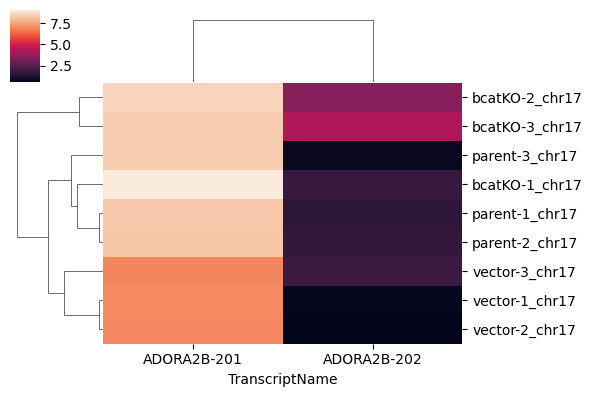

In [103]:
sns.clustermap(dfs.transpose(), figsize = (6,4), row_cluster = True)
plt.show()

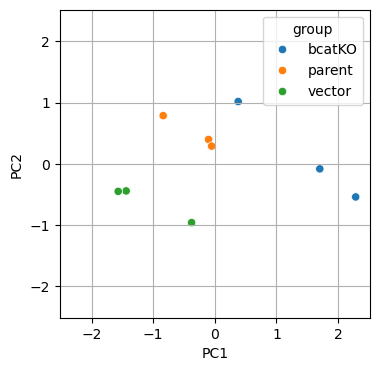

In [104]:
## PCA projection of Isoforms expressions

df_2d = deiso.DEiso_pca( dfs, n_comp = 2 )
df_pca = df_2d.transpose().copy(deep = True)
df_pca['group'] = list(groups)

plt.figure(figsize = (4,4))
sns.scatterplot(x = df_pca['PC1'], y = df_pca['PC2'], hue = df_pca['group'])
mxv = np.abs(df_pca[['PC1', 'PC2']]).max().max()*1.1
plt.xlim([-mxv, mxv])
plt.ylim([-mxv, mxv])
plt.grid()
plt.show()

## __4. Transcript expression quantification through Transcriptome assembly (StringTie)__ 
#### __StringTie workflow__

<!-- MLBI-EDU-NOTE: practice -->
이 단계에서는 BAM에서 transcript 구조를 조립하고, reference annotation에 없는 novel isoform 후보까지 포함한 정량을 시도합니다. StringTie 결과와 Salmon/RSEM 결과를 비교하면 annotation 의존성과 assembly 기반 접근의 차이를 볼 수 있습니다.


<div>
<img src="attachment:8c463d2e-5c51-425c-90cc-d96bf065f011.png" width="250"/>
</div>


In [5]:
!stringtie --version

2.2.1


#### __A. Run stringtie to get merged GFF file__
Merged GFF file may contain some novel isoforms <br>
and will be used as guide GTF for transcript/gene expression quantification

In [25]:
## Check data folder

src_dir = 'RNAseq_CRC_chr17_bam'
dlst = os.listdir(src_dir)
dlst.sort()
dlst

['bcatKO-1_chr17.bam',
 'bcatKO-1_chr17.bam.bai',
 'bcatKO-1_chr17.log',
 'bcatKO-2_chr17.bam',
 'bcatKO-2_chr17.bam.bai',
 'bcatKO-2_chr17.log',
 'bcatKO-3_chr17.bam',
 'bcatKO-3_chr17.bam.bai',
 'bcatKO-3_chr17.log',
 'parent-1_chr17.bam',
 'parent-1_chr17.bam.bai',
 'parent-1_chr17.log',
 'parent-2_chr17.bam',
 'parent-2_chr17.bam.bai',
 'parent-2_chr17.log',
 'parent-3_chr17.bam',
 'parent-3_chr17.bam.bai',
 'parent-3_chr17.log',
 'vector-1_chr17.bam',
 'vector-1_chr17.bam.bai',
 'vector-1_chr17.log',
 'vector-2_chr17.bam',
 'vector-2_chr17.bam.bai',
 'vector-2_chr17.log',
 'vector-3_chr17.bam',
 'vector-3_chr17.bam.bai',
 'vector-3_chr17.log']

In [26]:
df_bam_pair_lst = utl.get_bam_pair_list( src_dir, ext = 'bam' )
df_bam_pair_lst

,tumor_bam,normal_bam,tumor_RG,normal_RG
0,RNAseq_CRC_chr17_bam/bcatKO-1_chr17.bam,None,None,None
1,RNAseq_CRC_chr17_bam/bcatKO-2_chr17.bam,None,None,None
2,RNAseq_CRC_chr17_bam/bcatKO-3_chr17.bam,None,None,None
3,RNAseq_CRC_chr17_bam/parent-1_chr17.bam,None,None,None
4,RNAseq_CRC_chr17_bam/parent-2_chr17.bam,None,None,None
5,RNAseq_CRC_chr17_bam/parent-3_chr17.bam,None,None,None
6,RNAseq_CRC_chr17_bam/vector-1_chr17.bam,None,None,None
7,RNAseq_CRC_chr17_bam/vector-2_chr17.bam,None,None,None
8,RNAseq_CRC_chr17_bam/vector-3_chr17.bam,None,None,None


In [108]:
## Path + Prefix to Ref. Tr
## Source directory/file description
gtf_file = 'RefGenome_hg38_sel/Homo_sapiens_assembly38_chr7_12_17.gtf'

src_dir = 'RNAseq_CRC_chr17_bam'
out_dir = 'RNAseq_CRC_chr17_stringtie/'

if not os.path.isdir(out_dir):
    os.mkdir( out_dir )

In [110]:
for i, row in df_bam_pair_lst.iterrows():
    
    bam_file = row.tumor_bam
    print(bam_file)
    
    out_file_name, exp_file_name_t, cmd = tasm.Stringtie_run( bam_file, gtf_file = gtf_file, 
                                                              out_dir = out_dir, p = 4, 
                                                              options = '', out_texp = True )

## Aggregate stringtie results
df_tr_exp, df_g_exp = tasm.aggregate_stringtie_results(out_dir, gtf_file, col = 'TPM')

## Generate merged.gff
merged_gff, gffcompare_res = tasm.Stringtie_merge_n_compare( out_dir, gtf_file, out_dir = None )

RNAseq_CRC_chr17_bam/bcatKO-1_chr17.bam
Run stringtie for RNAseq_CRC_chr17_bam/bcatKO-1_chr17.bam
   with Guide GTF: RefGenome_hg38_sel/Homo_sapiens_assembly38_chr7_12_17.gtf
   GFF saved to RNAseq_CRC_chr17_stringtie/bcatKO-1_chr17.stringtie_gtf_guided.gff
Loading GTF ... done 465202 lines. 
Loading GTF ... done 30294 lines. 
N common transcripts: 2559 / 34802, 3529
RNAseq_CRC_chr17_bam/bcatKO-2_chr17.bam
Run stringtie for RNAseq_CRC_chr17_bam/bcatKO-2_chr17.bam
   with Guide GTF: RefGenome_hg38_sel/Homo_sapiens_assembly38_chr7_12_17.gtf
   GFF saved to RNAseq_CRC_chr17_stringtie/bcatKO-2_chr17.stringtie_gtf_guided.gff
Loading GTF ... done 465202 lines. 
Loading GTF ... done 29781 lines. 
N common transcripts: 2682 / 34802, 3775
RNAseq_CRC_chr17_bam/bcatKO-3_chr17.bam
Run stringtie for RNAseq_CRC_chr17_bam/bcatKO-3_chr17.bam
   with Guide GTF: RefGenome_hg38_sel/Homo_sapiens_assembly38_chr7_12_17.gtf
   GFF saved to RNAseq_CRC_chr17_stringtie/bcatKO-3_chr17.stringtie_gtf_guided.gff
Lo

In [111]:
df_tr_exp.head()

,bcatKO-1_chr17,bcatKO-2_chr17,bcatKO-3_chr17,parent-1_chr17,parent-2_chr17,parent-3_chr17,vector-1_chr17,vector-2_chr17,vector-3_chr17
tname,,,,,,,,,
AC215522.3-201,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AC215522.3-202,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AC215522.2-201,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AC215522.2-202,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AC215522.2-203,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [112]:
df_g_exp.to_csv('exp_g_stringtie.csv')
df_tr_exp.to_csv('exp_t_stringtie.csv')

#### __B. Gene/Transcript expression quantification <font color=blue>using StringTie with the merged GFF</font>__

In [113]:
df_bam_pair_lst

,tumor_bam,normal_bam,tumor_RG,normal_RG
0,RNAseq_CRC_chr17_bam/bcatKO-1_chr17.bam,None,None,None
1,RNAseq_CRC_chr17_bam/bcatKO-2_chr17.bam,None,None,None
2,RNAseq_CRC_chr17_bam/bcatKO-3_chr17.bam,None,None,None
3,RNAseq_CRC_chr17_bam/parent-1_chr17.bam,None,None,None
4,RNAseq_CRC_chr17_bam/parent-2_chr17.bam,None,None,None
5,RNAseq_CRC_chr17_bam/parent-3_chr17.bam,None,None,None
6,RNAseq_CRC_chr17_bam/vector-1_chr17.bam,None,None,None
7,RNAseq_CRC_chr17_bam/vector-2_chr17.bam,None,None,None
8,RNAseq_CRC_chr17_bam/vector-3_chr17.bam,None,None,None


In [20]:
merged_gff = 'RNAseq_CRC_chr17_stringtie_merged_info/merged_with_gffcompare.gff'

In [115]:
src_dir = 'RNAseq_CRC_chr17_bam'
out_dir_merged = 'RNAseq_CRC_chr17_stringtie_with_merged_gff'

if not os.path.isdir(out_dir):
    os.mkdir( out_dir )

In [116]:
for i, row in df_bam_pair_lst.iterrows():
    
    bam_file = row.tumor_bam
    print(bam_file)
    
    out_file_name, exp_file_name_t, cmd = tasm.Stringtie_run( bam_file, gtf_file = merged_gff, 
                                                              out_dir = out_dir_merged, p = 4, 
                                                              options = '', out_texp = True )

    df_bam_pair_lst.loc[i, 'stringtie_res'] = exp_file_name_t

df_tr_exp, df_g_exp = tasm.aggregate_stringtie_results(out_dir_merged, merged_gff, col = 'TPM')

RNAseq_CRC_chr17_bam/bcatKO-1_chr17.bam
Run stringtie for RNAseq_CRC_chr17_bam/bcatKO-1_chr17.bam
   with Guide GTF: RNAseq_CRC_chr17_stringtie_merged_info/merged_with_gffcompare.gff
   GFF saved to RNAseq_CRC_chr17_stringtie_with_merged_gff/bcatKO-1_chr17.stringtie_gtf_guided.gff
Loading GTF ... done 285680 lines. 
Loading GTF ... done 36596 lines. 
N common transcripts: 3445 / 38311, 3957
RNAseq_CRC_chr17_bam/bcatKO-2_chr17.bam
Run stringtie for RNAseq_CRC_chr17_bam/bcatKO-2_chr17.bam
   with Guide GTF: RNAseq_CRC_chr17_stringtie_merged_info/merged_with_gffcompare.gff
   GFF saved to RNAseq_CRC_chr17_stringtie_with_merged_gff/bcatKO-2_chr17.stringtie_gtf_guided.gff
Loading GTF ... done 285680 lines. 
Loading GTF ... done 35772 lines. 
N common transcripts: 3591 / 38311, 4229
RNAseq_CRC_chr17_bam/bcatKO-3_chr17.bam
Run stringtie for RNAseq_CRC_chr17_bam/bcatKO-3_chr17.bam
   with Guide GTF: RNAseq_CRC_chr17_stringtie_merged_info/merged_with_gffcompare.gff
   GFF saved to RNAseq_CRC_ch

In [117]:
df_tr_exp.head()

,bcatKO-1_chr17,bcatKO-2_chr17,bcatKO-3_chr17,parent-1_chr17,parent-2_chr17,parent-3_chr17,vector-1_chr17,vector-2_chr17,vector-3_chr17
tname,,,,,,,,,
DENND5B-202,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DENND5B-203,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DENND5B-204,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DENND5B-201,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DENND5B-207,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [118]:
df_g_exp.to_csv('exp_g_strg_strg.csv')
df_tr_exp.to_csv('exp_t_strg_strg.csv')

#### __Gene/Transcript expression quantification <font color=blue>using Salmon</font> with the merged GFF__

In [15]:
## Check data folder
src_dir = 'RNAseq_CRC_chr17'
dlst = os.listdir(src_dir)
dlst.sort()
dlst

['bcatKO-1_chr17_R1.fq.gz',
 'bcatKO-1_chr17_R2.fq.gz',
 'bcatKO-2_chr17_R1.fq.gz',
 'bcatKO-2_chr17_R2.fq.gz',
 'bcatKO-3_chr17_R1.fq.gz',
 'bcatKO-3_chr17_R2.fq.gz',
 'parent-1_chr17_R1.fq.gz',
 'parent-1_chr17_R2.fq.gz',
 'parent-2_chr17_R1.fq.gz',
 'parent-2_chr17_R2.fq.gz',
 'parent-3_chr17_R1.fq.gz',
 'parent-3_chr17_R2.fq.gz',
 'vector-1_chr17_R1.fq.gz',
 'vector-1_chr17_R2.fq.gz',
 'vector-2_chr17_R1.fq.gz',
 'vector-2_chr17_R2.fq.gz',
 'vector-3_chr17_R1.fq.gz',
 'vector-3_chr17_R2.fq.gz']

In [16]:
df_fq_pair_list = utl.get_fq_pair_list( src_dir, ext = 'fq.gz', 
                                    r1_key = '_R1', r2_key = '_R2' )

df_fq_pair_list['RG'] = [f.split('/')[-1].split('-')[0] for f in df_fq_pair_list['fq1']]
df_fq_pair_list['SM'] = [f.split('/')[-1].split('_')[0] for f in df_fq_pair_list['fq1']]

df_fq_pair_list

,fq1,fq2,RG,SM
0,RNAseq_CRC_chr17/bcatKO-1_chr17_R1.fq.gz,RNAseq_CRC_chr17/bcatKO-1_chr17_R2.fq.gz,bcatKO,bcatKO-1
1,RNAseq_CRC_chr17/bcatKO-2_chr17_R1.fq.gz,RNAseq_CRC_chr17/bcatKO-2_chr17_R2.fq.gz,bcatKO,bcatKO-2
2,RNAseq_CRC_chr17/bcatKO-3_chr17_R1.fq.gz,RNAseq_CRC_chr17/bcatKO-3_chr17_R2.fq.gz,bcatKO,bcatKO-3
3,RNAseq_CRC_chr17/parent-1_chr17_R1.fq.gz,RNAseq_CRC_chr17/parent-1_chr17_R2.fq.gz,parent,parent-1
4,RNAseq_CRC_chr17/parent-2_chr17_R1.fq.gz,RNAseq_CRC_chr17/parent-2_chr17_R2.fq.gz,parent,parent-2
5,RNAseq_CRC_chr17/parent-3_chr17_R1.fq.gz,RNAseq_CRC_chr17/parent-3_chr17_R2.fq.gz,parent,parent-3
6,RNAseq_CRC_chr17/vector-1_chr17_R1.fq.gz,RNAseq_CRC_chr17/vector-1_chr17_R2.fq.gz,vector,vector-1
7,RNAseq_CRC_chr17/vector-2_chr17_R1.fq.gz,RNAseq_CRC_chr17/vector-2_chr17_R2.fq.gz,vector,vector-2
8,RNAseq_CRC_chr17/vector-3_chr17_R1.fq.gz,RNAseq_CRC_chr17/vector-3_chr17_R2.fq.gz,vector,vector-3


In [21]:
merged_gff

'RNAseq_CRC_chr17_stringtie_merged_info/merged_with_gffcompare.gff'

In [22]:
## Source directory/file description
genome_dir = 'RefGenome_hg38_sel'
genome_file = genome_dir + '/Homo_sapiens_assembly38_chr7_12_17.fa'
guide_gtf_file = merged_gff

index_dir = 'index_salmon_stringtie_merged_gff'
index_dir

'index_salmon_stringtie_merged_gff'

In [123]:
salmon_idx, cmds = geq.salmon_PrepRef( genome_file, guide_gtf_file,
                                       index_dir = index_dir,
                                       verbose = False )
salmon_idx

'index_salmon_stringtie_merged_gff'

In [23]:
src_dir = 'RNAseq_CRC_chr17'
out_dir = 'RNAseq_CRC_chr17_salmon_with_merged_gff'

In [27]:
df_fq_pair_list['salmon_res'] = None

for j, row in df_fq_pair_list.iterrows():
    
    fq_l = row.fq1
    fq_r = row.fq2
    out_file_prefix = f'{out_dir}/' + '_'.join( fq_l.split('/')[-1].split('_')[:-1] )
    
    print(j, out_file_prefix)

    file_out, cmds = geq.salmon_CalcExp( fq_l, fq_r, index_dir, out_file_prefix, \
                                         p = 6, verbose = False)
    
    df_bam_pair_lst.loc[j, 'salmon_res'] = file_out

## Aggregate salmon result
df_tr_exp, df_g_exp = geq.aggregate_salmon_results(out_dir, merged_gff, col = 'TPM')    

0 RNAseq_CRC_chr17_salmon_with_merged_gff/bcatKO-1_chr17
running salmon quant .. 
Expression info. saved to .. 
   RNAseq_CRC_chr17_salmon_with_merged_gff/bcatKO-1_chr17.tr_exp.tsv 
1 RNAseq_CRC_chr17_salmon_with_merged_gff/bcatKO-2_chr17
running salmon quant .. 
Expression info. saved to .. 
   RNAseq_CRC_chr17_salmon_with_merged_gff/bcatKO-2_chr17.tr_exp.tsv 
2 RNAseq_CRC_chr17_salmon_with_merged_gff/bcatKO-3_chr17
running salmon quant .. 
Expression info. saved to .. 
   RNAseq_CRC_chr17_salmon_with_merged_gff/bcatKO-3_chr17.tr_exp.tsv 
3 RNAseq_CRC_chr17_salmon_with_merged_gff/parent-1_chr17
running salmon quant .. 
Expression info. saved to .. 
   RNAseq_CRC_chr17_salmon_with_merged_gff/parent-1_chr17.tr_exp.tsv 
4 RNAseq_CRC_chr17_salmon_with_merged_gff/parent-2_chr17
running salmon quant .. 
Expression info. saved to .. 
   RNAseq_CRC_chr17_salmon_with_merged_gff/parent-2_chr17.tr_exp.tsv 
5 RNAseq_CRC_chr17_salmon_with_merged_gff/parent-3_chr17
running salmon quant .. 
Expressi

In [28]:
df_tr_exp.head()

,bcatKO-1_chr17,bcatKO-2_chr17,bcatKO-3_chr17,parent-1_chr17,parent-2_chr17,parent-3_chr17,vector-1_chr17,vector-2_chr17,vector-3_chr17
TranscriptName,,,,,,,,,
PDE3A-202,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
AC015813.2-j1739.12,1293.938214,814.086983,840.062132,1574.151153,1398.029153,1499.670347,1616.243882,1655.802886,1581.190827
ITGA7-219,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
EIF4EP2-201,0.000000,0.000000,0.000000,79.396721,64.891301,115.133327,0.000000,0.000000,0.000000
KRIT1-218,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [29]:
df_g_exp.head()

,bcatKO-1_chr17,bcatKO-2_chr17,bcatKO-3_chr17,parent-1_chr17,parent-2_chr17,parent-3_chr17,vector-1_chr17,vector-2_chr17,vector-3_chr17
AC073878.2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
P3H4,278.730264,273.534042,254.207656,312.906964,361.000116,337.445314,374.845643,361.417705,354.101635
CCDC71L,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
SPECC1P2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
SCARNA11,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [128]:
df_g_exp.to_csv('exp_g_strg_salmon.csv')
df_tr_exp.to_csv('exp_t_strg_salmon.csv')

#### __Compare salmon with stringtie results__

In [30]:
df_g_exp = pd.read_csv('exp_g_strg_salmon.csv', index_col = 0)
df_tr_exp = pd.read_csv('exp_t_strg_salmon.csv', index_col = 0)

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

In [32]:
lst = ['rsem', 'salmon', 'strg_strg', 'strg_salmon']
lst = ['salmon', 'strg_strg', 'strg_salmon']

df_t = {}
tns = {}
for i in lst:
    df_t[i] = pd.read_csv( f'exp_t_{i}.csv', index_col = 0 )
    tns[i] = df_t[i].index.values.tolist()

tns_cmn = tns[i]
for i in lst:
    tns_cmn = list(set(tns_cmn).intersection(tns[i]))
    print(f'# of entries in {i} = {len(tns[i])}')
    
print(f'# of common entries = {len(tns_cmn)}')

# of entries in salmon = 34718
# of entries in strg_strg = 38311
# of entries in strg_salmon = 38217
# of common entries = 34700


In [33]:
lst

['salmon', 'strg_strg', 'strg_salmon']

In [34]:
c = df_t[i].columns.values.tolist()[0]

df_comb = pd.DataFrame(index = tns_cmn)
for i in lst:
    df_comb[i] = df_t[i][c]

b = df_comb.sum(axis = 1) != 0
df_comb = np.log10( df_comb.loc[b] + 0.01)
df_comb.head()

,salmon,strg_strg,strg_salmon
MYO15B-203,0.437222,-2.000000,0.774057
AC004590.1-201,0.461078,-2.000000,-2.000000
SLC25A39-203,1.112607,-2.000000,1.121603
PFAS-203,0.881250,-2.000000,0.940899
COX11-201,2.504355,2.798673,2.582670


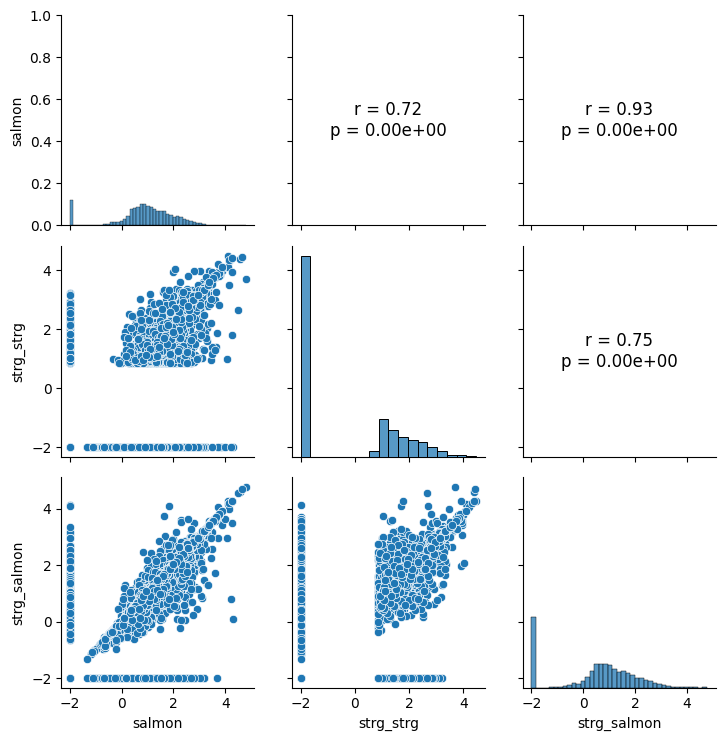

In [35]:
# ──────────────────────────────────────────────
# 1. 상관계수 표시 함수 정의
# ──────────────────────────────────────────────
def corrfunc(x, y, **kws):
    b = (x > -2) & (y > -2)
    r, p = pearsonr(x[b], y[b])
    ax = plt.gca()
    ax.annotate(f"r = {r:.2f}\np = {p:.2e}", 
                xy=(.5, .5), xycoords=ax.transAxes,
                ha='center', va='center', fontsize=12)

# ──────────────────────────────────────────────
# 2. PairGrid + map_upper 사용하여 pairplot 확장
# ──────────────────────────────────────────────
def pairplot_with_corr(df):
    grid = sns.PairGrid(df)
    grid = grid.map_upper(corrfunc)           # 상단 패널에 상관계수
    grid = grid.map_lower(sns.scatterplot)    # 하단 패널은 scatter
    grid = grid.map_diag(sns.histplot)        # diagonal은 hist
    return grid

# 예시 실행
g = pairplot_with_corr(df_comb)
plt.show()


In [36]:
df_expr = np.log2( 1 + df_g_exp )
group = [c.split('-')[0] for c in df_expr.columns]
np.array(group)

array(['bcatKO', 'bcatKO', 'bcatKO', 'parent', 'parent', 'parent',
       'vector', 'vector', 'vector'], dtype='<U6')

In [37]:
dct_deg, dct_deg_all = deg.simple_DEG( df_expr, group, 
                                   ref_condition = 'vector', ## None for One-vs-the-Rest 
                                   pval_cutoff = 0.05,
                                   logFC_cutoff = 0.5,
                                   test_method = "ols",
                                   corr_method = "fdr_bh")
dct_deg.keys()

### MODE: one-vs-reference (vector) ###
Significant DEGs (bcatKO vs vector) = 62 (up 18, down 44) genes.
Significant DEGs (parent vs vector) = 160 (up 121, down 39) genes.


dict_keys(['bcatKO_vs_vector', 'parent_vs_vector'])

In [38]:
dct_deg['bcatKO_vs_vector'].to_csv('deg_t_strg_salmon.csv')

In [43]:
lst = ['rsem', 'salmon', 'strg_salmon']
lst = ['salmon', 'strg_salmon']

df_t = {}
tns = {}
for i in lst:
    df_t[i] = pd.read_csv( f'deg_t_{i}.csv', index_col = 0 )
    tns[i] = df_t[i].index.values.tolist()

tns_cmn = tns[i]
for i in lst:
    tns_cmn = list(set(tns_cmn).union(tns[i]))
    print(f'# of entries in {i} = {len(tns[i])}')
    
print(f'# of common entries = {len(tns_cmn)}')

# of entries in salmon = 115
# of entries in strg_salmon = 62
# of common entries = 0


In [40]:
lst

['salmon', 'strg_salmon']

In [41]:
c = df_t[i].columns.values.tolist()[0]

df_comb = pd.DataFrame(index = tns_cmn)
for i in lst:
    df_comb.loc[df_t[i].index, i] = df_t[i][c]

df_comb.head()

,salmon,strg_salmon
RPL26-210,3.557375,NaN
AC099850.3-201,-2.224938,NaN
LRRC45,NaN,0.800818
RF00017.140-201,-3.414653,NaN
RNF167-210,-2.885822,NaN


In [ ]:
g = pairplot_with_corr(df_comb)

In [44]:
lst = ['salmon', 'strg_strg', 'strg_salmon']

df_t = {}
tns = {}
for i in lst:
    df_t[i] = pd.read_csv( f'exp_t_{i}.csv', index_col = 0 )
    tns[i] = df_t[i].index.values.tolist()


In [45]:
groups = [c.split('-')[0] for c in df_t[i].columns]
np.array( groups )

array(['bcatKO', 'bcatKO', 'bcatKO', 'parent', 'parent', 'parent',
       'vector', 'vector', 'vector'], dtype='<U6')

In [46]:
df = df_t['strg_salmon']
df.head()

,bcatKO-1_chr17,bcatKO-2_chr17,bcatKO-3_chr17,parent-1_chr17,parent-2_chr17,parent-3_chr17,vector-1_chr17,vector-2_chr17,vector-3_chr17
TranscriptName,,,,,,,,,
NTS-201,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
RNF10-214,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
MSTRG.2024.1,0.0,0.0,0.0,11.884845,0.000000,0.000000,0.000000,0.000000,8.327305
KANSL2-213,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
AC004797.1-201,0.0,0.0,0.0,0.000000,0.304793,0.331954,0.266264,0.216204,0.542326


In [47]:
ref_group = 'vector'
item = 'bcatKO_vs_vector'

df_deiso_res = {}
for i in lst:
    df = df_t[i]
    
    df_res = deiso.DEiso_anal( df, groups, ref_group = ref_group,
                               norm = True, log = True, n_pca_comp = 4, 
                               verbose = True )
    df_deiso_res[i] = df_res[item]

DEiso done (6) .. 609                      
DEiso done (5) .. 407                      
DEiso done (7) .. 643                      


In [149]:
tns_cmn = df_deiso_res[i].index.values.tolist()
for i in lst:
    tns_cmn = list(set(tns_cmn).intersection(df_deiso_res[i].index.values.tolist()))
    print(f'# of entries in {i} = {len(tns[i])}')
    
print(f'# of common entries = {len(tns_cmn)}')

# of entries in salmon = 34718
# of entries in strg_strg = 38311
# of entries in strg_salmon = 38217
# of common entries = 121


In [150]:
tns_cmn.sort()
tns_cmn

['AARSD1',
 'AC016876.1',
 'AC068152.1',
 'AC087289.1',
 'ACADVL',
 'ACBD4',
 'ACOX1',
 'ACTG1',
 'AMZ2',
 'ARHGAP23',
 'ARHGDIA',
 'ARSG',
 'ATP6V0A1',
 'ATXN7L3',
 'B9D1',
 'BPTF',
 'BRCA1',
 'C17orf49',
 'C17orf58',
 'CBX2',
 'CCDC47',
 'CDC6',
 'CDK5RAP3',
 'CENPV',
 'CEP131',
 'CEP95',
 'CTDNEP1',
 'DDX5',
 'DPH1',
 'DUSP14',
 'EIF4A3',
 'EMC6',
 'ENO3',
 'EPN2',
 'G6PC3',
 'GOSR1',
 'GPS2',
 'GRN',
 'HDAC5',
 'HOXB2',
 'HOXB3',
 'HOXB6',
 'HOXB7',
 'HOXB8',
 'ITGB4',
 'KAT2A',
 'LGALS3BP',
 'LINC00868',
 'LLGL2',
 'LUC7L3',
 'MAP3K3',
 'MED11',
 'MED24',
 'MINK1',
 'MKS1',
 'MPDU1',
 'MPRIP',
 'MRM3',
 'MRPL45',
 'MSI2',
 'MYO19',
 'NAA38',
 'NBR2',
 'NCBP3',
 'NDUFAF8',
 'NLK',
 'NME2',
 'NOL11',
 'NT5C3B',
 'NT5M',
 'OGFOD3',
 'OXLD1',
 'P3H4',
 'P4HB',
 'PFN1',
 'PIGW',
 'PIMREG',
 'PRKAR1A',
 'PSMB3',
 'PSMD11',
 'PYCR1',
 'RARA',
 'RECQL5',
 'RFNG',
 'RHOT1',
 'RNF157',
 'RNF167',
 'RNFT1',
 'RPAIN',
 'RPH3AL',
 'RPL23',
 'RPL38',
 'SEPT4',
 'SKAP1',
 'SLC39A11',
 'SNF8',
 '

In [151]:
i = 'strg_salmon'
df = df_t[i]

In [152]:
groups = [c.split('-')[0] for c in df.columns]
np.array( groups )

array(['bcatKO', 'bcatKO', 'bcatKO', 'parent', 'parent', 'parent',
       'vector', 'vector', 'vector'], dtype='<U6')

In [153]:
ref_group = 'vector'
df_res_all = deiso.DEiso_anal( df, groups, ref_group = ref_group,
                         norm = True, log = True, n_pca_comp = 4, 
                         verbose = True )

DEiso done (7) .. 643                      


In [154]:
df_res = df_res_all['bcatKO_vs_vector'].sort_values('pval')
b = df_res['pval'] <= 0.05
df_res = df_res.loc[b, :]
df_res

,stat,pval,Niso,DoF,F-stat,pval_adj
RAMP2,305231392.965954,0.000043,13,1,305231392.965954,0.020563
TMEM105,27229065.37255,0.000144,5,1,27229065.37255,0.068703
SUMO2,3293.024383,0.000304,3,2,3293.024383,0.144815
HSD17B1,58069.741587,0.003112,6,1,58069.741587,1.000000
AC090627.1,23696.02399,0.004872,4,1,23696.02399,1.000000
SHMT1,20886.278161,0.00519,14,1,20886.278161,1.000000
KLHL11,42.531521,0.006288,2,3,42.531521,1.000000
EPN2,8478.145289,0.008145,35,1,8478.145289,1.000000
MIR2117HG,7018.910082,0.008952,5,1,7018.910082,1.000000
YBX2,6415.983514,0.009363,8,1,6415.983514,1.000000


In [155]:
deiso.save_to_excel(df_res_all, f'CRC_deiso_results_{i}.xlsx')

In [156]:
## load deiso results
df_res_all = deiso.load_excel(f'CRC_deiso_results_{i}.xlsx')

In [157]:
df_res_all.keys()

dict_keys(['bcatKO_vs_vector', 'parent_vs_vector'])

In [158]:
## Select one
df_res = df_res_all['bcatKO_vs_vector'].sort_values('pval')
b = df_res['pval'] <= 0.05
df_res = df_res.loc[b, :]
df_res

,stat,pval,Niso,DoF,F-stat,pval_adj
RAMP2,3.052314e+08,0.000043,13,1,3.052314e+08,0.020563
TMEM105,2.722907e+07,0.000144,5,1,2.722907e+07,0.068703
SUMO2,3.293024e+03,0.000304,3,2,3.293024e+03,0.144815
HSD17B1,5.806974e+04,0.003112,6,1,5.806974e+04,1.000000
AC090627.1,2.369602e+04,0.004872,4,1,2.369602e+04,1.000000
SHMT1,2.088628e+04,0.005190,14,1,2.088628e+04,1.000000
KLHL11,4.253152e+01,0.006288,2,3,4.253152e+01,1.000000
EPN2,8.478145e+03,0.008145,35,1,8.478145e+03,1.000000
MIR2117HG,7.018910e+03,0.008952,5,1,7.018910e+03,1.000000
YBX2,6.415984e+03,0.009363,8,1,6.415984e+03,1.000000


In [159]:
# df = df_tr_exp
# df = dft_all_merged
gene_names = [s.split('-')[0] for s in list(df.index.values)]

In [160]:
## select a gene
selection = 2
gene = df_res.index.values[selection]
print(gene)

## Check isoform expression for the selected gene
b = pd.Series(gene_names, index = df.index) == gene

dfs = df.loc[b,:].copy(deep = True)
dfs = dfs.div(dfs.sum(axis = 0), axis = 1)*100
dfs = np.log2(dfs + 1)
dfs

SUMO2


,bcatKO-1_chr17,bcatKO-2_chr17,bcatKO-3_chr17,parent-1_chr17,parent-2_chr17,parent-3_chr17,vector-1_chr17,vector-2_chr17,vector-3_chr17
TranscriptName,,,,,,,,,
SUMO2-203,4.036111,3.662441,3.137959,4.241145,4.223152,4.141838,4.136039,4.124229,4.190395
SUMO2-202,4.708447,4.770716,4.878288,4.281641,4.242774,4.412528,4.109165,4.108634,4.113179
SUMO2-201,5.917665,5.978198,6.017613,6.014353,6.031026,6.001144,6.090858,6.094022,6.075469


In [161]:
groups, ref_group

(['bcatKO',
  'bcatKO',
  'bcatKO',
  'parent',
  'parent',
  'parent',
  'vector',
  'vector',
  'vector'],
 'vector')

In [162]:
import seaborn as sns
import matplotlib.pyplot as plt

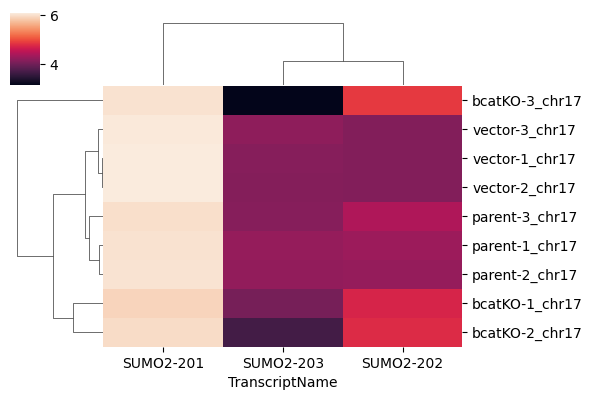

In [163]:
sns.clustermap(dfs.transpose(), figsize = (6,4), row_cluster = True)
plt.show()

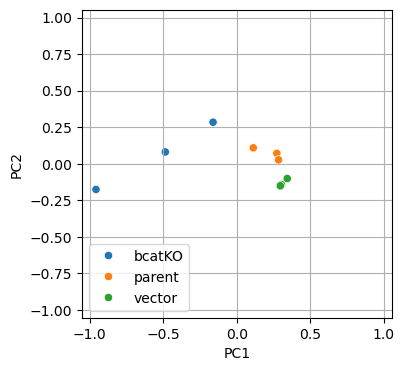

In [164]:
## PCA projection of Isoforms expressions

df_2d = deiso.DEiso_pca( dfs, n_comp = 2 )
df_pca = df_2d.transpose().copy(deep = True)
df_pca['group'] = list(groups)

plt.figure(figsize = (4,4))
sns.scatterplot(x = df_pca['PC1'], y = df_pca['PC2'], hue = df_pca['group'])
mxv = np.abs(df_pca[['PC1', 'PC2']]).max().max()*1.1
plt.xlim([-mxv, mxv])
plt.ylim([-mxv, mxv])
plt.legend(loc = 'lower left')
plt.grid()
plt.show()

## __5. Quantifying alternative splicing using RMATS__

<!-- MLBI-EDU-NOTE: practice -->
이 단계에서는 exon skipping, alternative splice site, retained intron 같은 splicing event를 정량합니다. DEG는 gene abundance 변화에 민감하고, rMATS는 isoform 구조 변화에 민감하므로 두 결과를 함께 비교하는 것이 좋습니다.


In [4]:
!rmats.py --version

v4.3.0


In [15]:
src_dir = 'RNAseq_CRC_chr17_bam'
flst = os.listdir(src_dir)
flst.sort()
flst = [s for s in flst if s.split('.')[-1] == 'bam']
flst

['bcatKO-1_chr17.bam',
 'bcatKO-2_chr17.bam',
 'bcatKO-3_chr17.bam',
 'parent-1_chr17.bam',
 'parent-2_chr17.bam',
 'parent-3_chr17.bam',
 'vector-1_chr17.bam',
 'vector-2_chr17.bam',
 'vector-3_chr17.bam']

In [16]:
groups = [f.split('-')[0] for f in flst]
group_lst = list(set(groups))
group_lst

['bcatKO', 'vector', 'parent']

#### __A. Prepare input BAM list__

In [21]:
from collections import defaultdict
import os

bam_dict = defaultdict(list)

for f in flst:
    g = f.split("-")[0]
    bam_dict[g].append(os.path.join(src_dir, f))

for g in group_lst:
    with open(f"{g}.txt", "wt") as fp:
        fp.write(",".join(bam_dict[g]))

#### __B. Run RMATs__

In [43]:
t1, t2 = 'bcatKO', 'vector'

gtf_file = 'RefGenome_hg38_sel/Homo_sapiens_assembly38_chr7_12_17.gtf'

out_dir = src_dir + '_rmats'
if not os.path.isdir(out_dir): 
    os.mkdir(out_dir)

In [23]:
b1 = f"{t1}.txt"
b2 = f"{t2}.txt"

tasm.rMATs_run( b1, b2, gtf_file, rd_type = 'paired', 
                rd_len = 100, n_thred = 4, out_dir = out_dir, 
                lib_type = 'fr-firststrand', verbose = True )

gtf: 2.6383798122406006
There are 8922 distinct gene ID in the gtf file
There are 34802 distinct transcript ID in the gtf file
There are 5337 one-transcript genes in the gtf file
There are 214097 exons in the gtf file
There are 3746 one-exon transcripts in the gtf file
There are 3283 one-transcript genes with only one exon in the transcript
Average number of transcripts per gene is 3.900695
Average number of exons per transcript is 6.151859
Average number of exons per transcript excluding one-exon tx is 6.773281
Average number of gene per geneGroup is 1.954154
statistic: 0.01217031478881836

read outcome totals across all BAMs
USED: 23795054
NOT_PAIRED: 0
NOT_NH_1: 745992
NOT_EXPECTED_CIGAR: 296248
NOT_EXPECTED_READ_LENGTH: 0
NOT_EXPECTED_STRAND: 0
EXON_NOT_MATCHED_TO_ANNOTATION: 353339
JUNCTION_NOT_MATCHED_TO_ANNOTATION: 80437
CLIPPED: 0
total: 25271070
outcomes by BAM written to: rmats_tmp/2026-06-22-03_02_50_051318_read_outcomes_by_bam.txt

novel: 16.780076503753662
The splicing gra

'rmats.py --gtf RefGenome_hg38_sel/Homo_sapiens_assembly38_chr7_12_17.gtf --b1 bcatKO.txt --b2 vector.txt -t paired --readLength 100 --nthread 4 --od RNAseq_CRC_chr17_bam_rmats --tmp rmats_tmp --libType fr-firststrand --allow-clipping --variable-read-length '

#### __C. Get results in data frames__

In [24]:
df_summary, df_rmats, df_results = tasm.rMATs_summarize_result( out_dir, pval_cutoff = 0.05 )

In [25]:
df_summary

,pval_min,pval_max,FDR_min,FDR_max,MXE,SE,RI,A3SS,A5SS
ACADVL,1.216360e-12,0.041512,2.631761e-11,0.430957,0,0,0,0,19
SLC25A39,0.000000e+00,0.021592,0.000000e+00,0.238552,0,0,0,0,18
VMP1,0.000000e+00,0.044184,0.000000e+00,0.129860,0,0,0,0,15
RPAIN,6.104350e-07,0.045788,9.461742e-06,0.461819,0,0,0,0,12
HOXB3,2.083863e-07,0.000016,1.064665e-05,0.000468,0,0,0,0,10
...,...,...,...,...,...,...,...,...,...
RPL38,0.000000e+00,0.000000,0.000000e+00,0.000000,0,0,0,0,1
ABCC3,1.919022e-04,0.000192,1.388093e-03,0.001388,0,0,0,0,1
H3F3B,0.000000e+00,0.000000,0.000000e+00,0.000000,0,0,0,0,1
USP36,3.311552e-03,0.003312,1.399082e-02,0.013991,0,0,0,0,1


In [26]:
df_rmats

,AS_type,GeneID,geneSymbol,chr,strand,ID.1,IJC_SAMPLE_1,SJC_SAMPLE_1,IJC_SAMPLE_2,SJC_SAMPLE_2,...,exonStart_0base,exonEnd,riExonStart_0base,riExonEnd,longExonStart_0base,longExonEnd,shortES,shortEE,flankingES,flankingEE
6,MXE,ENSG00000141580,WDR45B,chr17,-,6,"6,5,1","328,139,89","16,21,16","420,576,406",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,MXE,ENSG00000141580,WDR45B,chr17,-,9,"152,44,40","139,39,26","195,248,224","458,524,460",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,MXE,ENSG00000141568,FOXK2,chr17,+,10,"98,57,37","225,96,70","361,462,374","335,403,327",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,MXE,ENSG00000141568,FOXK2,chr17,+,11,"96,57,37","448,197,169","360,458,370","667,785,658",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,MXE,ENSG00000141568,FOXK2,chr17,+,12,"136,63,41","447,197,169","311,340,284","668,788,662",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6664,A5SS,ENSG00000167880,EVPL,chr17,-,995,"4,5,1","38,33,22","1,1,0","22,40,39",...,NaN,NaN,NaN,NaN,76018094,76018258,76018160,76018258,76017738,76017911
6673,A5SS,ENSG00000141576,RNF157,chr17,-,1073,"0,1,1","18,3,3","2,1,4","21,10,10",...,NaN,NaN,NaN,NaN,76154279,76154328,76154282,76154328,76152354,76152465
6675,A5SS,ENSG00000169718,DUS1L,chr17,-,1095,"9,19,16","558,655,491","7,6,5","423,548,449",...,NaN,NaN,NaN,NaN,82060860,82060961,82060864,82060961,82060700,82060783
6678,A5SS,ENSG00000141376,BCAS3,chr17,+,1099,"2,4,2","0,0,0","11,12,3","0,5,0",...,NaN,NaN,NaN,NaN,60887049,60887211,60887049,60887126,60889694,60889771


In [27]:
df_results.keys()

dict_keys(['MXE', 'SE', 'RI', 'A3SS', 'A5SS'])

In [28]:
df_results['MXE']

,AS_type,GeneID,geneSymbol,chr,strand,1stExonStart_0base,1stExonEnd,2ndExonStart_0base,2ndExonEnd,upstreamES,...,SJC_SAMPLE_1,IJC_SAMPLE_2,SJC_SAMPLE_2,IncFormLen,SkipFormLen,PValue,FDR,IncLevel1,IncLevel2,IncLevelDifference
ID,,,,,,,,,,,,,,,,,,,,,
0,MXE,ENSG00000141556,TBCD,chr17,+,82893546,82893632,82900650,82900731,82884144,...,"73,39,31","6,4,3","60,66,82",185,180,0.094395,0.218825,"0.038,0.048,0.0","0.089,0.056,0.034",-0.031
1,MXE,ENSG00000141556,TBCD,chr17,+,82900650,82900731,82903404,82903478,82893546,...,"51,25,11","123,88,113","74,89,94",180,173,0.229997,0.403198,"0.562,0.618,0.694","0.615,0.487,0.536",0.079
2,MXE,ENSG00000141556,TBCD,chr17,+,82900650,82900731,82903404,82903478,82893546,...,"2,1,2","123,87,114","7,3,1",180,173,0.945891,1.000000,"0.97,0.975,0.92","0.944,0.965,0.991",-0.012
3,MXE,ENSG00000141556,TBCD,chr17,+,82903404,82903478,82911757,82911789,82893546,...,"26,25,13","7,3,1","44,39,59",173,131,0.594908,0.782484,"0.08,0.029,0.104","0.108,0.055,0.013",0.012
4,MXE,ENSG00000141556,TBCD,chr17,+,82903404,82903478,82911757,82911789,82900541,...,"24,22,11","57,62,68","42,38,55",173,131,0.333873,0.518229,"0.679,0.482,0.508","0.507,0.553,0.484",0.042
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
974,MXE,ENSG00000169718,DUS1L,chr17,-,82063467,82063518,82064125,82064234,82062860,...,"145,107,78","527,646,509","227,312,243",208,150,0.035133,0.101558,"0.68,0.668,0.631","0.626,0.599,0.602",0.051
975,MXE,ENSG00000141376,BCAS3,chr17,+,60688019,60688195,60688931,60689046,60683981,...,"2,0,0","0,2,2","1,1,0",275,214,1.000000,1.000000,"0.0,NA,NA","0.0,0.609,1.0",-0.536
976,MXE,ENSG00000141376,BCAS3,chr17,+,61380505,61380571,61388617,61388708,61368326,...,"2,8,15","3,11,11","18,11,2",165,190,0.599387,0.786481,"0.801,0.697,0.35","0.161,0.535,0.864",0.096


### __Compare with DEiso__
#### A. Get DEiso results

In [32]:
## load deiso results
df_res_all = deiso.load_excel('deiso_results_for_bcatKO_vs_vector.xlsx')

In [33]:
df_res_all.keys()

dict_keys(['bcatKO_vs_vector', 'parent_vs_vector'])

In [35]:
## Select one
df_deiso_res = df_res_all['bcatKO_vs_vector'].copy(deep = True)
b = df_deiso_res['pval'] <= 0.1
df_deiso_res = df_deiso_res.loc[b, :]
df_deiso_res

,stat,pval,Niso,DoF,F-stat,pval_adj
ADORA2B,166.095309,0.000847,2,3,166.095309,0.080439
LINC00674,106.592286,0.001635,2,3,106.592286,0.153664
RPL27,88.820347,0.002140,8,3,88.820347,0.199040
NUFIP2,76.003646,0.002692,2,3,76.003646,0.247709
KPNB1,74.629042,0.002766,14,3,74.629042,0.251682
H3F3B,61.672224,0.003659,13,3,61.672224,0.329299
ITGB4,38.006260,0.007398,13,3,38.006260,0.658458
AC008105.1,33.497927,0.008873,2,3,33.497927,0.780829
THRA,32.265776,0.009363,10,3,32.265776,0.814594
ATP5MC1,31.320748,0.009770,10,3,31.320748,0.840258


In [37]:
## Get RSEM results (saved)

df = pd.read_csv('exp_t_salmon.csv', index_col = 0)
df.head()

,bcatKO-1_chr17,bcatKO-2_chr17,bcatKO-3_chr17,parent-1_chr17,parent-2_chr17,parent-3_chr17,vector-1_chr17,vector-2_chr17,vector-3_chr17
TranscriptName,,,,,,,,,
NTS-201,0.0,0.0,0.0,0.0,0.000000,0.00000,0.000000,0.000000,0.000000
RNF10-214,0.0,0.0,0.0,0.0,0.000000,0.00000,0.000000,0.000000,0.000000
KANSL2-213,0.0,0.0,0.0,0.0,0.000000,0.00000,0.000000,0.000000,0.000000
AC004797.1-201,0.0,0.0,0.0,0.0,0.275334,0.29964,0.241893,0.196213,0.492888
GFAP-201,0.0,0.0,0.0,0.0,0.000000,0.00000,0.000000,0.000000,0.000000


In [38]:
gene_names = [s.split('-')[0] for s in df.index.values ]

groups = []
for c in df.columns.values:
    groups.append( c.split('_')[0] )
np.array( groups )

array(['bcatKO-1', 'bcatKO-2', 'bcatKO-3', 'parent-1', 'parent-2',
       'parent-3', 'vector-1', 'vector-2', 'vector-3'], dtype='<U8')

In [39]:
groups

['bcatKO-1',
 'bcatKO-2',
 'bcatKO-3',
 'parent-1',
 'parent-2',
 'parent-3',
 'vector-1',
 'vector-2',
 'vector-3']

In [40]:
## Select only two
target_groups = ['V', 'b-cat-KO']
b = pd.Series(groups, index = df.columns).isin(target_groups)

df_sel = df.loc[:,b]
groups_sel = list(np.array(groups)[np.array(b)])

In [41]:
df_sel

""
TranscriptName
NTS-201
RNF10-214
KANSL2-213
AC004797.1-201
GFAP-201
...
AC004160.1-207
SUN1-218
ST8SIA1-201


#### B. Compare rmats result with DEiso

In [45]:
path_to_rMAT = 'run_rmats'
path_to_gtf = 'RefGenome/Homo_sapiens_assembly38_chr17.gtf'

df_rmats_res, df_rmat_summary = tasm.get_rmats_summary( out_dir, pval_cutoff = 0.001, 
                         as_lst = ['MXE', 'SE', 'RI', 'A3SS', 'A5SS'])

In [46]:
df_rmats_res

,pval_min,pval_max,FDR_min,FDR_max,MXE,SE,RI,A3SS,A5SS
SLC25A39,0.000000e+00,9.973531e-04,0.000000e+00,5.236104e-03,8,0,2,0,0
ACADVL,1.216360e-12,1.280569e-04,2.631761e-11,3.077437e-03,3,1,4,1,0
VMP1,0.000000e+00,7.464218e-04,0.000000e+00,2.477154e-02,5,3,0,0,0
HOXB-AS3,0.000000e+00,1.298291e-04,0.000000e+00,6.729234e-03,0,7,0,0,0
RAD51C,0.000000e+00,9.465887e-04,0.000000e+00,1.612069e-02,5,0,0,1,0
...,...,...,...,...,...,...,...,...,...
PTGES3L-AARSD1,8.951058e-04,8.951058e-04,2.142287e-02,2.142287e-02,0,0,0,0,1
NCBP3,6.746239e-06,6.746239e-06,6.054749e-04,6.054749e-04,0,0,0,0,1
JPT1,9.231504e-13,9.231504e-13,3.314110e-10,3.314110e-10,0,0,0,0,1
ANKRD13B,2.738265e-05,2.738265e-05,1.591479e-03,1.591479e-03,0,0,0,0,1


In [47]:
genes_2 = list(df_rmats_res.index.values)
genes_1 = list(df_deiso_res.index.values)

genes_c = list(set(genes_1).intersection(genes_2))

len(genes_c), len(genes_1), len(genes_2)

(13, 36, 234)

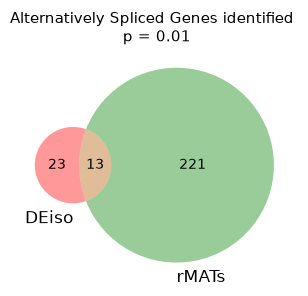

In [52]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

plt.figure(figsize = (4,3))

venn2([set(genes_1),set(genes_2)], 
      ('DEiso','rMATs'))
plt.title('Alternatively Spliced Genes identified \n p = 0.01', fontsize = 11 )
plt.show()

In [53]:
df_deiso_res.loc[genes_c, :].iloc[:20]

,stat,pval,Niso,DoF,F-stat,pval_adj
ATP5MC1,31.320748,0.009770,10,3,31.320748,0.840258
H3F3B,61.672224,0.003659,13,3,61.672224,0.329299
CENPV,9.096609,0.053258,7,3,9.096609,1.000000
MPDU1,9.836047,0.048133,27,3,9.836047,1.000000
HGS,8.772228,0.055801,17,3,8.772228,1.000000
TRAF4,29.904799,0.010439,17,3,29.904799,0.887282
PSMD12,21.430756,0.016731,8,3,21.430756,1.000000
NME2,8.272113,0.060139,9,3,8.272113,1.000000
SLFN12L,15.295803,0.026689,5,3,15.295803,1.000000
C1QBP,12.736641,0.034200,7,3,12.736641,1.000000


In [54]:
df_rmats_res.loc[genes_c, :].iloc[:20]

,pval_min,pval_max,FDR_min,FDR_max,MXE,SE,RI,A3SS,A5SS
ATP5MC1,7.938678e-06,7.938678e-06,2.614109e-04,2.614109e-04,0,0,0,1,0
H3F3B,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0,1,0,0
CENPV,9.727319e-11,5.784894e-09,6.410303e-08,4.063888e-07,0,1,0,1,0
MPDU1,0.000000e+00,3.838595e-09,0.000000e+00,5.374033e-08,4,0,0,0,0
HGS,7.026735e-11,7.026735e-11,2.541336e-09,2.541336e-09,0,0,1,0,0
TRAF4,1.128928e-07,1.128928e-07,1.388350e-05,1.388350e-05,0,0,0,0,1
PSMD12,0.000000e+00,5.936541e-04,0.000000e+00,3.364040e-03,3,0,0,0,0
NME2,4.743340e-04,4.743340e-04,1.764599e-02,1.764599e-02,0,1,0,0,0
SLFN12L,1.020610e-06,1.020610e-06,1.384728e-04,1.384728e-04,0,1,0,0,0
C1QBP,9.729362e-04,9.729362e-04,5.145751e-03,5.145751e-03,1,0,0,0,0
